import gzip, io, re, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns# Dublin Airbnb -- Data Cleaning, Feature Engineering & SQL Aggregations
### Adapted from the Amsterdam pipeline

**Data:** [Inside Airbnb](http://insideairbnb.com/get-the-data/) - Dublin

---

**Conventions:**
- All transformations use **pandas method chaining** -- `.pipe()`, `.assign()`, `.query()`.
- SQL queries use **pandasql** (SQLite syntax) on the cleaned DataFrame.
- Comments explain *why*, not just *what*.


In [39]:
import gzip, io, re, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [40]:
from sklearn.impute import SimpleImputer

# ── Scikit-learn: model selection & evaluation ────────────────────────────────
# train_test_split  : splits data into training and test sets
# cross_validate    : runs k-fold cross-validation and returns multiple metrics
# GridSearchCV      : exhaustively searches hyperparameter combinations
# StratifiedKFold   : k-fold that preserves the class ratio in every fold
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
# StandardScaler  : rescales numeric features to mean=0, std=1 (Z-score normalisation)
# OneHotEncoder   : converts text categories (e.g. 'male'/'female') to 0/1 columns
# LabelEncoder    : encodes a single target column as integers (used in simple LR demos)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# ── Scikit-learn: pipeline plumbing ───────────────────────────────────────────
# ColumnTransformer : applies different transformers to different columns simultaneously
# Pipeline          : chains preprocessing + model into one object, preventing data leakage
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Scikit-learn: classifiers ─────────────────────────────────────────────────
# LogisticRegression      : linear model; predicts class probabilities via the sigmoid function
# DecisionTreeClassifier  : tree of yes/no questions; interpretable but prone to overfitting
# RandomForestClassifier  : ensemble of many decision trees; robust and accurate
# GradientBoostingClassifier : sklearn's built-in boosting (slower than XGBoost/LightGBM)
# KNeighborsClassifier    : classifies by majority vote of the k nearest training points
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# ── Scikit-learn: evaluation metrics ──────────────────────────────────────────
# accuracy_score      : proportion of all predictions that are correct
# precision_score     : of all predicted positives, how many were actually positive?
# recall_score        : of all actual positives, how many did we catch? (sensitivity)
# f1_score            : harmonic mean of precision and recall; balances both
# roc_auc_score       : area under the ROC curve; threshold-independent measure of ranking ability
# confusion_matrix    : 2×2 table of TP/TN/FP/FN counts
# roc_curve           : computes the full TPR/FPR curve across all thresholds
# classification_report: prints precision/recall/F1 for every class at once
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)
from sklearn.model_selection import cross_validate  # Import for multi-metric support

# ── Gradient Boosting libraries (not part of sklearn core) ────────────────────
# LightGBM and XGBoost are specialist boosting libraries maintained separately.
# They are faster and often more accurate than sklearn's GradientBoostingClassifier.
# if you have a mac, you need to run `brew install libomp` and restart your kernel
# this will install OpenMP (Open Multi-Processing) to handle parallel computing on macOS
from lightgbm import LGBMClassifier           # Import the Light Gradient Boosting Machine classifier
from xgboost import XGBClassifier             # Import the eXtreme Gradient Boosting classifier

# ── Model interpretability ────────────────────────────────────────────────────
# shap : computes Shapley values — tells us HOW MUCH and IN WHICH DIRECTION
#        each feature pushed a particular prediction. Used in the final section.
import shap

# ── Housekeeping ──────────────────────────────────────────────────────────────
# Suppress convergence and deprecation warnings to keep notebook output readable.
# In production code you would NOT suppress warnings.
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style for all seaborn plots (light grey grid background)
sns.set_style("whitegrid")
# Set the default figure size for all matplotlib plots to

---
## 1. Setup & Configuration


In [41]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

AIRBNB_PALETTE = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676', '#FFB400']
sns.set_theme(style='whitegrid', palette=AIRBNB_PALETTE, font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

CITY_NAME = 'Dublin'
SEED      = 123

print(f'Setup complete -- analysing {CITY_NAME}')


Setup complete -- analysing Dublin


---
## 2. Data Acquisition

Data loaded directly from GitHub -- no manual upload needed.


In [42]:
GITHUB_BASE = 'https://github.com/yanazzz315-cloud/Dublin-Listing/raw/main/'

LISTINGS_GZ_URL     = GITHUB_BASE + 'listings.csv.gz'
REVIEWS_CSV_URL     = GITHUB_BASE + 'reviews.csv'
NEIGHBOURHOODS_URL  = GITHUB_BASE + 'neighbourhoods.csv'
GEOJSON_URL         = GITHUB_BASE + 'neighbourhoods.geojson'
CALENDAR_GZ_URL     = GITHUB_BASE + 'calendar.csv.gz'
LISTINGS_SIMPLE_URL = GITHUB_BASE + 'listings.csv'

print(f'GitHub URLs configured for {CITY_NAME}')


GitHub URLs configured for Dublin


In [43]:
listings_raw = pd.read_csv(LISTINGS_GZ_URL, low_memory=False)
print(f'Listings (detailed): {len(listings_raw):,} rows x {listings_raw.shape[1]} cols')

reviews_raw = pd.read_csv(REVIEWS_CSV_URL, low_memory=False)
print(f'Reviews: {len(reviews_raw):,} rows x {reviews_raw.shape[1]} cols')

print('\nListing columns:', listings_raw.columns.tolist())
print('\nReviews columns:', reviews_raw.columns.tolist())


Listings (detailed): 6,945 rows x 79 cols
Reviews: 334,122 rows x 2 cols

Listing columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_update

---
## 3. Data Cleaning & Feature Engineering

Single pandas method chain -- each `.pipe()` is a named, testable function.

1. Parse price strings to float
2. Enforce numeric dtypes
3. Engineer business-meaningful derived features
4. Drop rows missing critical fields
5. Remove extreme price outliers


In [44]:
def parse_price(df):
    """Strip currency symbols and commas, then coerce to float."""
    return df.assign(
        price=lambda x: (
            x['price'].astype(str)
            .str.replace(r'[\$\u20ac,]', '', regex=True)
            .pipe(pd.to_numeric, errors='coerce')
        )
    )

def parse_numeric_cols(df):
    """Coerce columns that should be numeric but may arrive as strings."""
    cols = [
        'review_scores_rating', 'review_scores_cleanliness',
        'review_scores_communication', 'review_scores_location',
        'review_scores_value', 'accommodates', 'bedrooms', 'beds',
        'minimum_nights', 'number_of_reviews',
        'calculated_host_listings_count', 'latitude', 'longitude'
    ]
    existing = [c for c in cols if c in df.columns]
    return df.assign(**{c: pd.to_numeric(df[c], errors='coerce') for c in existing})

def add_derived_features(df):
    """Engineer business-meaningful features."""
    return df.assign(
        price_per_person=lambda x: x['price'] / x['accommodates'].replace(0, np.nan),
        host_age_years=lambda x: (
            (pd.Timestamp.now() - pd.to_datetime(x.get('host_since'), errors='coerce'))
            .dt.days / 365
        ),
        host_identity_verified=lambda x: (
            x.get('host_identity_verified', pd.Series('f', index=x.index))
             .map({'t': 1, 'f': 0})
        ),
        is_superhost=lambda x: (
            x.get('host_is_superhost', pd.Series('f', index=x.index))
             .map({'t': 1, 'f': 0})
        ),
        log_price=lambda x: np.log1p(x['price'])
    )

def handle_missing_values(df):
    """Drop rows missing lat/lon/price -- cannot model without these."""
    return df.dropna(subset=['latitude', 'longitude', 'price'])

def filter_price_outliers(df, lo=15, hi=1000):
    """Remove <15 (data errors) and >1000 (ultra-luxury, <1% of data)."""
    return df.query('@lo <= price <= @hi')

df = (
    listings_raw
    .pipe(parse_price)
    .pipe(parse_numeric_cols)
    .pipe(add_derived_features)
    .pipe(handle_missing_values)
    .pipe(filter_price_outliers)
    .reset_index(drop=True)
)

print(f'Clean dataset: {len(df):,} listings  (started with {len(listings_raw):,})')
print(f'Neighbourhoods: {df["neighbourhood_cleansed"].nunique()}')
print(f'Room types: {df["room_type"].value_counts().to_dict()}')
df[['price', 'accommodates', 'bedrooms', 'review_scores_rating', 'host_age_years']].describe().T


Clean dataset: 5,196 listings  (started with 6,945)
Neighbourhoods: 4
Room types: {'Entire home/apt': 2916, 'Private room': 2213, 'Shared room': 64, 'Hotel room': 3}


,count,mean,std,min,25%,50%,75%,max
price,5196.00,181.45,139.83,16.00,89.00,136.00,228.00,1000.00
accommodates,5196.00,3.25,2.08,1.00,2.00,2.00,4.00,16.00
bedrooms,5181.00,1.57,1.02,0.00,1.00,1.00,2.00,17.00
review_scores_rating,4438.00,4.74,0.38,1.00,4.67,4.85,4.98,5.00
host_age_years,5195.00,7.63,3.86,0.52,3.74,8.49,10.59,16.32


### 3.1 Missing-Value Audit


In [45]:
missing_report = (
    df.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .rename('n_missing')
    .to_frame()
    .assign(pct=lambda x: (x['n_missing'] / len(df) * 100).round(1))
    .head(25)
)
print(f'Columns with missing values: {len(missing_report)}')
missing_report


Columns with missing values: 25


,n_missing,pct
license,5196,100.00
calendar_updated,5196,100.00
neighbourhood_group_cleansed,5196,100.00
neighbourhood,3330,64.10
neighborhood_overview,3330,64.10
host_about,3095,59.60
host_location,1323,25.50
host_neighbourhood,1035,19.90
review_scores_accuracy,758,14.60
review_scores_location,758,14.60


### 3.2 Quick Sanity Checks


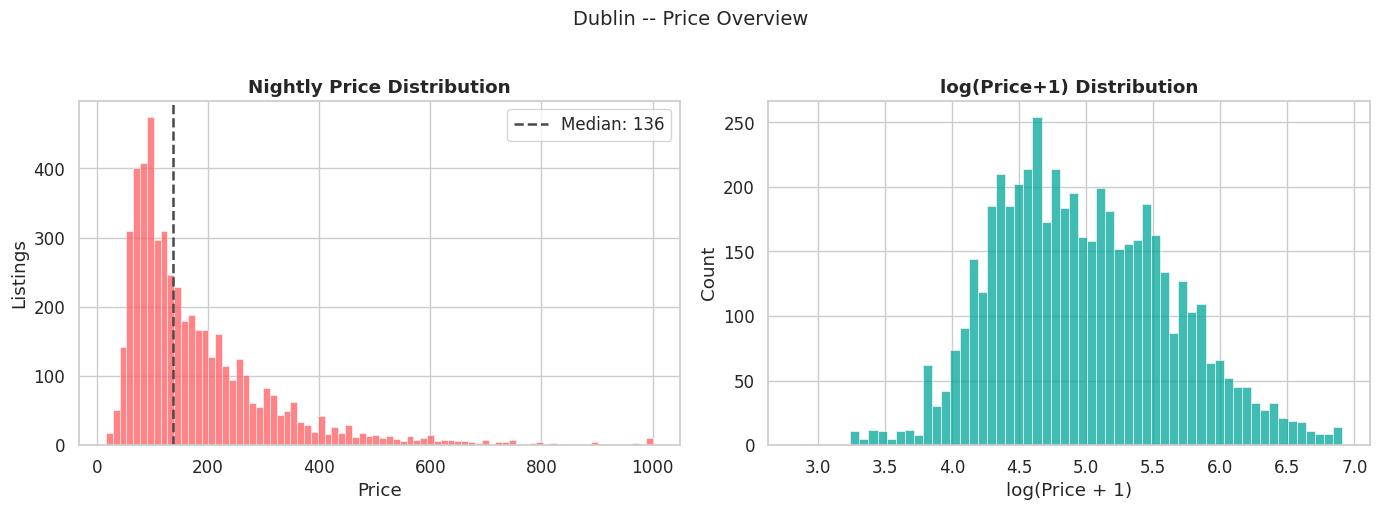

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=80, color='#FF5A5F', edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].axvline(df['price'].median(), color='#484848', linestyle='--', linewidth=1.8,
                label=f'Median: {df["price"].median():.0f}')
axes[0].set_title('Nightly Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price'); axes[0].set_ylabel('Listings'); axes[0].legend()

sns.histplot(df['log_price'], bins=60, color='#00A699', edgecolor='white', linewidth=0.4, ax=axes[1])
axes[1].set_title('log(Price+1) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')

plt.suptitle(f'{CITY_NAME} -- Price Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


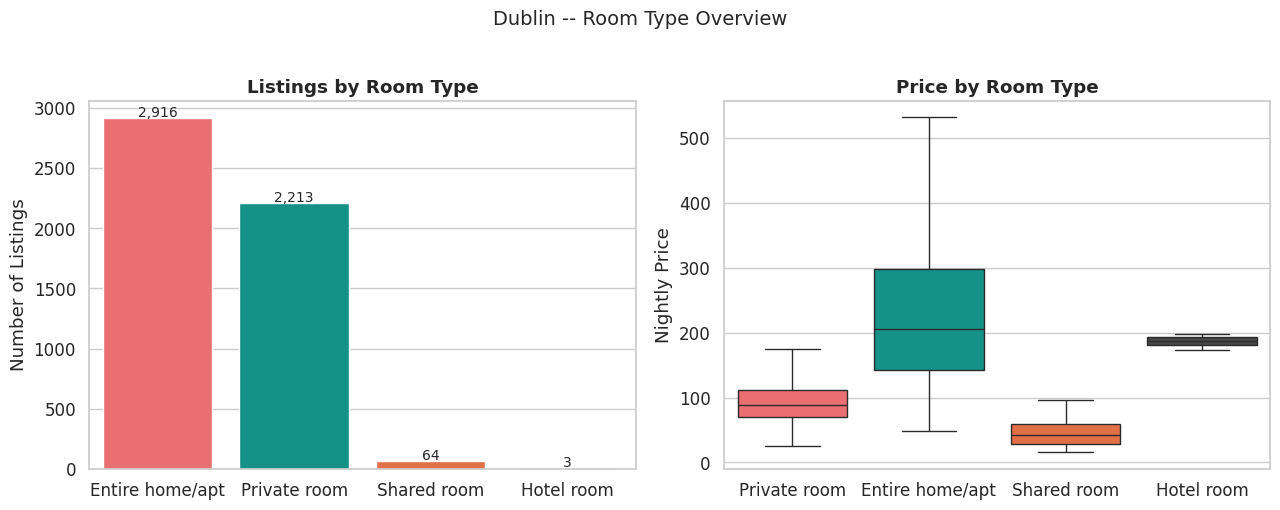

In [47]:
room_counts = df['room_type'].value_counts().reset_index()
room_counts.columns = ['room_type', 'n_listings']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=room_counts, x='room_type', y='n_listings', palette=AIRBNB_PALETTE, ax=axes[0])
axes[0].set_title('Listings by Room Type', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Number of Listings')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

sns.boxplot(data=df, x='room_type', y='price', palette=AIRBNB_PALETTE, showfliers=False, ax=axes[1])
axes[1].set_title('Price by Room Type', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Nightly Price')

plt.suptitle(f'{CITY_NAME} -- Room Type Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [48]:
nbhd_summary = (
    df
    .groupby('neighbourhood_cleansed', as_index=False)
    .agg(
        listings        = ('price', 'count'),
        median_price    = ('price', 'median'),
        avg_rating      = ('review_scores_rating', 'mean'),
        pct_superhost   = ('is_superhost', 'mean'),
        avg_host_tenure = ('host_age_years', 'mean')
    )
    .sort_values('median_price', ascending=False)
    .round(2)
)
print(f'{len(nbhd_summary)} neighbourhoods')
nbhd_summary


4 neighbourhoods


,neighbourhood_cleansed,listings,median_price,avg_rating,pct_superhost,avg_host_tenure
1,Dublin City,3465,150.00,4.72,0.33,7.67
0,Dn Laoghaire-Rathdown,617,137.00,4.84,0.27,8.22
2,Fingal,688,106.00,4.81,0.39,7.44
3,South Dublin,426,91.50,4.73,0.28,6.70


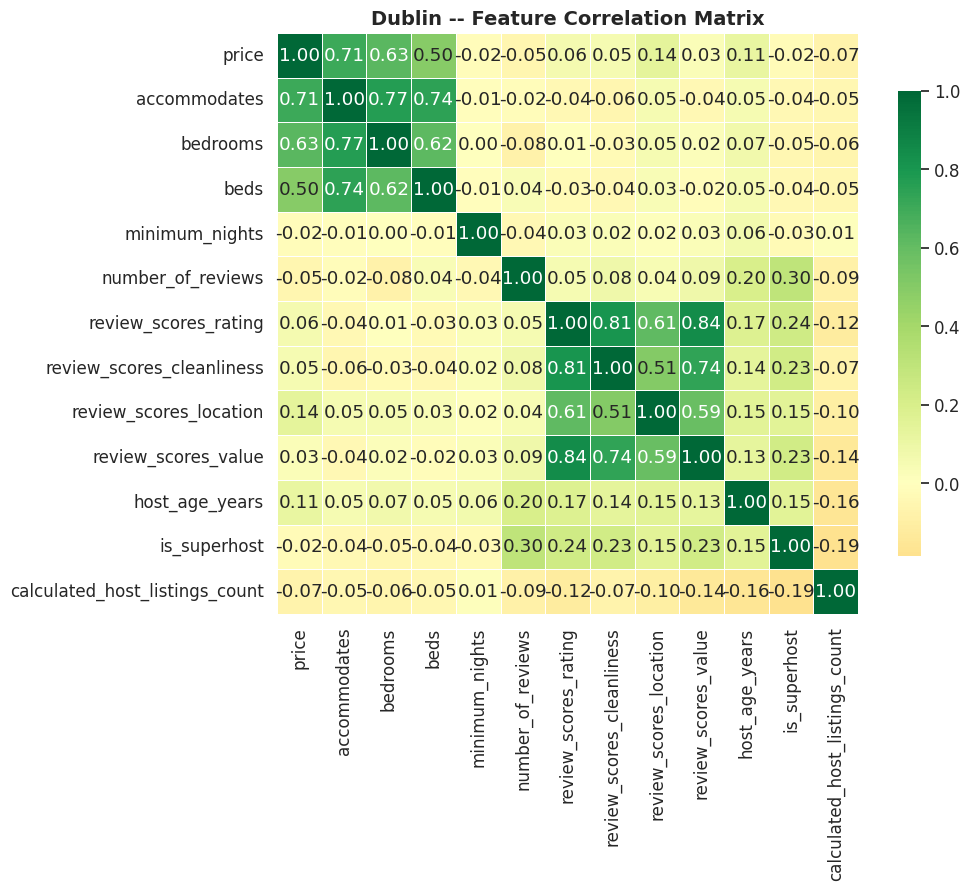

In [49]:
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_age_years', 'is_superhost', 'calculated_host_listings_count'
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title(f'{CITY_NAME} -- Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. SQL Queries for Aggregations

The project brief requires **SQL for aggregations and filtering**.
We use `pandasql` (SQLite syntax) to query the cleaned DataFrame directly.

Each query answers a specific question relevant to **predicting nightly prices**.


In [50]:
# Install pandasql if needed
try:
    from pandasql import sqldf
    print('pandasql loaded')
except ImportError:
    !pip install -q pandasql
    from pandasql import sqldf
    print('pandasql installed and loaded')

# Helper: run SQL against local variables
def sql(query):
    return sqldf(query, globals())


pandasql loaded


### 4.1 Neighbourhood Price Summary
Which neighbourhoods are most expensive? Key input for the regression model's location feature.


In [51]:
q1 = sql("""
    SELECT
        neighbourhood_cleansed          AS neighbourhood,
        COUNT(*)                        AS n_listings,
        ROUND(AVG(price), 2)            AS avg_price,
        ROUND(MIN(price), 2)            AS min_price,
        ROUND(MAX(price), 2)            AS max_price,
        ROUND(AVG(price_per_person), 2) AS avg_price_per_person
    FROM df
    GROUP BY neighbourhood_cleansed
    HAVING n_listings >= 10
    ORDER BY avg_price DESC
""")
q1


,neighbourhood,n_listings,avg_price,min_price,max_price,avg_price_per_person
0,Dublin City,3465,191.16,16.00,1000.00,61.63
1,Dn Laoghaire-Rathdown,617,187.58,34.00,1000.00,58.70
2,Fingal,688,158.20,26.00,975.00,52.38
3,South Dublin,426,131.07,30.00,1000.00,50.46


### 4.2 Average Price by Room Type and Neighbourhood
Room type is one of the strongest predictors of price. This cross-tabulation shows how the effect varies by location.


In [52]:
q2 = sql("""
    SELECT
        neighbourhood_cleansed  AS neighbourhood,
        room_type,
        COUNT(*)                AS n_listings,
        ROUND(AVG(price), 2)    AS avg_price,
        ROUND(AVG(review_scores_rating), 2) AS avg_rating
    FROM df
    GROUP BY neighbourhood_cleansed, room_type
    HAVING n_listings >= 5
    ORDER BY neighbourhood, avg_price DESC
""")
print(f'{len(q2)} rows')
q2.head(20)


9 rows


,neighbourhood,room_type,n_listings,avg_price,avg_rating
0,Dn Laoghaire-Rathdown,Entire home/apt,376,243.00,4.85
1,Dn Laoghaire-Rathdown,Private room,239,101.52,4.82
2,Dublin City,Entire home/apt,2088,245.80,4.71
3,Dublin City,Private room,1315,110.49,4.75
4,Dublin City,Shared room,59,55.86,4.16
5,Fingal,Entire home/apt,298,235.06,4.78
6,Fingal,Private room,388,99.80,4.84
7,South Dublin,Entire home/apt,154,221.58,4.68
8,South Dublin,Private room,271,79.76,4.76


### 4.3 Superhost Price Premium
Does the Superhost badge correlate with higher prices? Grouped by room type to control for listing type.


In [53]:
q3 = sql('''
    SELECT
        room_type,
        CASE WHEN is_superhost = 1 THEN 'Superhost' ELSE 'Non-superhost' END AS host_status,
        COUNT(*)                                    AS n_listings,
        ROUND(AVG(price), 2)                        AS avg_price,
        ROUND(AVG(review_scores_rating), 2)         AS avg_rating,
        ROUND(AVG(number_of_reviews), 1)            AS avg_reviews
    FROM df
    GROUP BY room_type, host_status
    ORDER BY room_type, host_status
''')
q3


,room_type,host_status,n_listings,avg_price,avg_rating,avg_reviews
0,Entire home/apt,Non-superhost,2061,243.71,4.67,34.80
1,Entire home/apt,Superhost,855,241.49,4.86,108.70
2,Hotel room,Non-superhost,3,186.67,4.20,36.30
3,Private room,Non-superhost,1460,106.84,4.71,28.80
4,Private room,Superhost,753,98.14,4.88,97.90
5,Shared room,Non-superhost,61,56.80,4.16,63.90
6,Shared room,Superhost,3,35.33,5.00,1.70


### 4.4 Price by Guest Capacity
Accommodates is a key regression feature. This query shows the price step-up per additional guest.


In [54]:
q4 = sql('''
    SELECT
        accommodates,
        COUNT(*)                    AS n_listings,
        ROUND(AVG(price), 2)        AS avg_price,
        ROUND(AVG(bedrooms), 1)     AS avg_bedrooms,
        ROUND(AVG(beds), 1)         AS avg_beds
    FROM df
    WHERE accommodates <= 10
    GROUP BY accommodates
    ORDER BY accommodates
''')
q4


,accommodates,n_listings,avg_price,avg_bedrooms,avg_beds
0,1,627,76.41,1.00,1.30
1,2,2204,119.25,1.00,1.10
2,3,293,160.38,1.30,1.90
3,4,1018,220.65,1.80,2.10
4,5,278,276.16,2.50,3.00
5,6,440,329.69,2.60,3.40
6,7,113,361.35,3.30,4.50
7,8,129,414.95,3.70,5.00
8,9,23,435.52,4.10,6.00
9,10,33,504.61,4.30,6.40


### 4.5 High-Availability vs Low-Availability Listings
Listings with very low availability may be inactive or seasonal. This compares pricing between availability tiers.


In [55]:
q5 = sql('''
    SELECT
        CASE
            WHEN availability_365 = 0                  THEN 'Unavailable'
            WHEN availability_365 BETWEEN 1 AND 90     THEN 'Low (1-90 days)'
            WHEN availability_365 BETWEEN 91 AND 270   THEN 'Medium (91-270 days)'
            ELSE 'High (271-365 days)'
        END AS availability_tier,
        COUNT(*)                            AS n_listings,
        ROUND(AVG(price), 2)                AS avg_price,
        ROUND(AVG(minimum_nights), 1)       AS avg_min_nights,
        ROUND(AVG(number_of_reviews), 1)    AS avg_reviews
    FROM df
    GROUP BY availability_tier
    ORDER BY avg_price DESC
''')
q5


,availability_tier,n_listings,avg_price,avg_min_nights,avg_reviews
0,High (271-365 days),1441,188.36,7.00,46.60
1,Medium (91-270 days),1896,184.99,5.30,63.90
2,Unavailable,51,182.33,4.20,27.30
3,Low (1-90 days),1808,172.19,3.80,52.40


### 4.6 Multi-Listing Hosts vs Single-Listing Hosts
The project brief mentions host characteristics. Are professional multi-listers pricing differently?


In [56]:
q6 = sql('''
    SELECT
        CASE
            WHEN calculated_host_listings_count = 1 THEN '1 listing'
            WHEN calculated_host_listings_count BETWEEN 2 AND 5 THEN '2-5 listings'
            ELSE '6+ listings'
        END AS host_portfolio,
        COUNT(*)                                    AS n_listings,
        ROUND(AVG(price), 2)                        AS avg_price,
        ROUND(AVG(review_scores_rating), 2)         AS avg_rating,
        ROUND(AVG(is_superhost) * 100, 1)           AS pct_superhost
    FROM df
    GROUP BY host_portfolio
    ORDER BY n_listings DESC
''')
q6


,host_portfolio,n_listings,avg_price,avg_rating,pct_superhost
0,1 listing,2413,195.17,4.81,28.50
1,2-5 listings,1515,155.38,4.76,45.70
2,6+ listings,1268,186.47,4.58,23.70


### 4.7 Price Tiers vs Review Scores
Do more expensive listings get better reviews? Checks whether review scores are a useful feature or a target leakage risk.


In [57]:
q7 = sql('''
    SELECT
        CASE
            WHEN price < 80   THEN '1. Budget (<80)'
            WHEN price < 150  THEN '2. Mid (80-149)'
            WHEN price < 300  THEN '3. Upper (150-299)'
            ELSE '4. Premium (300+)'
        END AS price_tier,
        COUNT(*)                                        AS n_listings,
        ROUND(AVG(review_scores_rating), 3)             AS avg_overall,
        ROUND(AVG(review_scores_cleanliness), 3)        AS avg_clean,
        ROUND(AVG(review_scores_location), 3)           AS avg_location,
        ROUND(AVG(review_scores_value), 3)              AS avg_value
    FROM df
    WHERE review_scores_rating IS NOT NULL
    GROUP BY price_tier
    ORDER BY price_tier
''')
q7


,price_tier,n_listings,avg_overall,avg_clean,avg_location,avg_value
0,1. Budget (<80),849,4.72,4.68,4.67,4.63
1,2. Mid (80-149),1610,4.76,4.74,4.75,4.63
2,3. Upper (150-299),1372,4.71,4.70,4.79,4.57
3,4. Premium (300+),607,4.78,4.74,4.82,4.64


### 4.8 Minimum Night Requirements
Identifies listings with unusual minimum-night policies that may need special treatment in the model.


In [58]:
q8 = sql('''
    SELECT
        CASE
            WHEN minimum_nights = 1 THEN '1 night'
            WHEN minimum_nights BETWEEN 2 AND 3 THEN '2-3 nights'
            WHEN minimum_nights BETWEEN 4 AND 7 THEN '4-7 nights'
            WHEN minimum_nights BETWEEN 8 AND 30 THEN '8-30 nights'
            ELSE '30+ nights'
        END AS min_night_bucket,
        COUNT(*)                    AS n_listings,
        ROUND(AVG(price), 2)        AS avg_price,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM df), 1) AS pct_of_total
    FROM df
    GROUP BY min_night_bucket
    ORDER BY n_listings DESC
''')
q8


,min_night_bucket,n_listings,avg_price,pct_of_total
0,2-3 nights,2249,196.49,43.30
1,1 night,1727,148.35,33.20
2,8-30 nights,586,170.39,11.30
3,4-7 nights,580,236.20,11.20
4,30+ nights,54,145.09,1.00


#5. Exploratory Data Analysis (EDA)
**Business question:** *What drives nightly prices on Dublin Airbnb, and how does listing quality vary across the city?*

###5.1 Missingness heatmap
Informs which columns need imputation in the ML pipeline

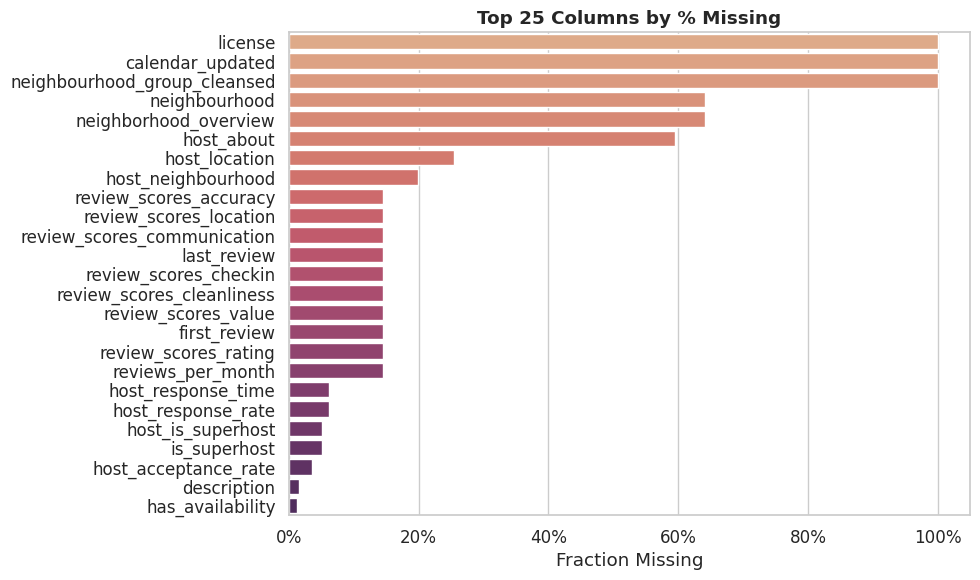

In [59]:
miss = (
    df.isnull().mean()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
    .head(25)
    .rename('pct_missing')
    .to_frame()
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=miss.reset_index(), x='pct_missing', y='index', palette='flare', ax=ax)
ax.set_title('Top 25 Columns by % Missing', fontweight='bold')
ax.set_xlabel('Fraction Missing'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

### 5.2 Correlation matrix
Shows linear relationships between numeric features and price;
review scores are highly co-linear — important for model design choices.

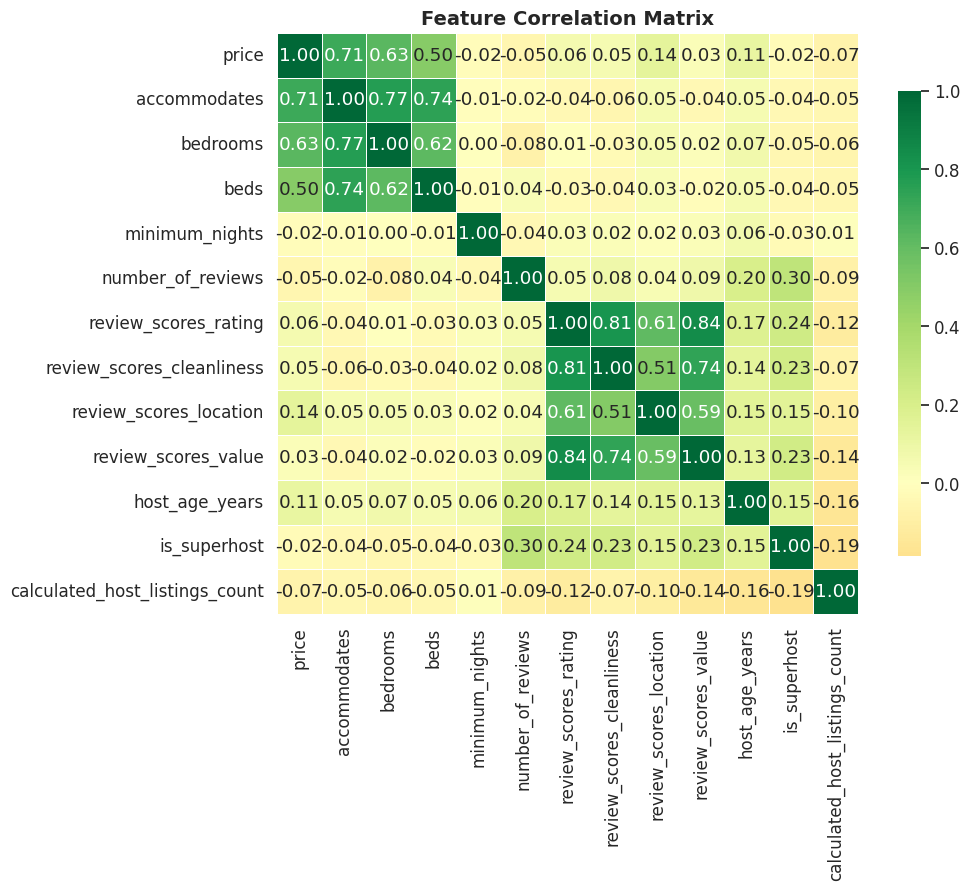

In [60]:

corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_age_years', 'is_superhost', 'calculated_host_listings_count'
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

From the linear visualization, nightly prices on Dublin Airbnb are driven primarily by listing size, capacity, and room type rather than by review activity or minimum-stay rules. The correlation matrix shows that price is strongly positively associated with accommodates (0.71), bedrooms (0.63), and beds (0.50), indicating that larger properties command higher nightly rates. This pattern is reinforced by the room-type analysis, where entire homes/apartments are both the most common and the most expensive category, while private rooms are cheaper and shared rooms occupy the low-price end of the market. By contrast, variables such as minimum_nights and number_of_reviews show little linear relationship with price, suggesting they are not major direct drivers of nightly rates.

###5.3 Room-type breakdown (count + price distribution)

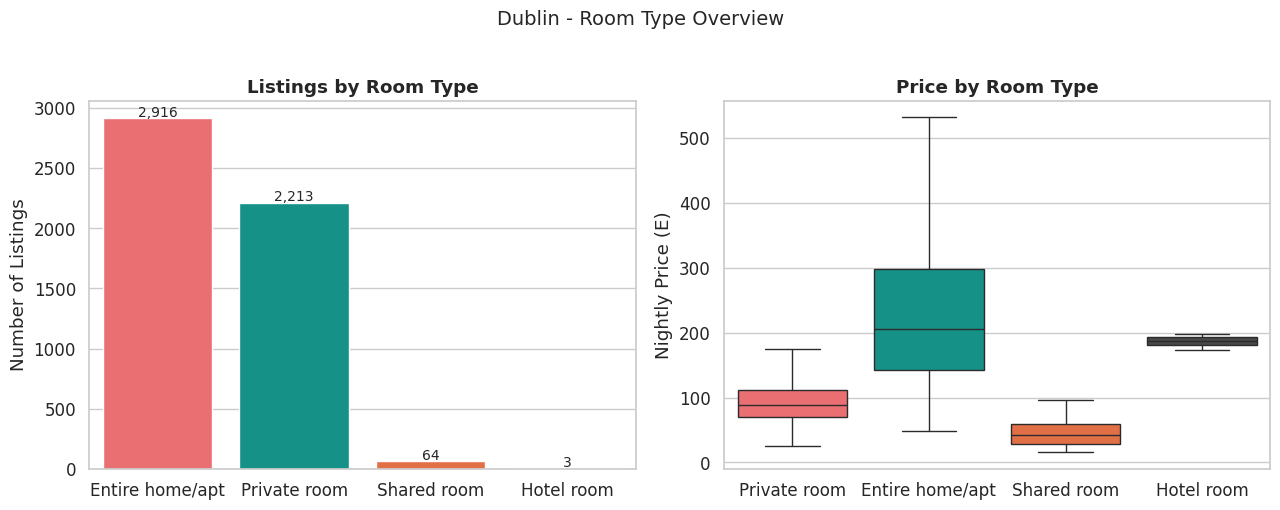

In [61]:

room_counts = df['room_type'].value_counts().reset_index().rename(columns={'count': 'n_listings'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=room_counts,
    x='room_type',
    y='n_listings',
    palette=AIRBNB_PALETTE,
    ax=axes[0])
axes[0].set_title('Listings by Room Type', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Number of Listings')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

sns.boxplot(data=df, x='room_type', y='price', palette=AIRBNB_PALETTE, showfliers=False, ax=axes[1])
axes[1].set_title('Price by Room Type', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Nightly Price (E)')

plt.suptitle(f'{CITY_NAME} - Room Type Overview', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Entire homes command the highest price because they provide privacy and full property access.
Shared rooms represent budget accommodation.
The price distribution for entire homes is much wider, suggesting greater variability in property size and quality.

###  5.4 Monthly review volume — booking demand proxy
Inside Airbnb: ~50-70% of stays generate a review — useful demand proxy

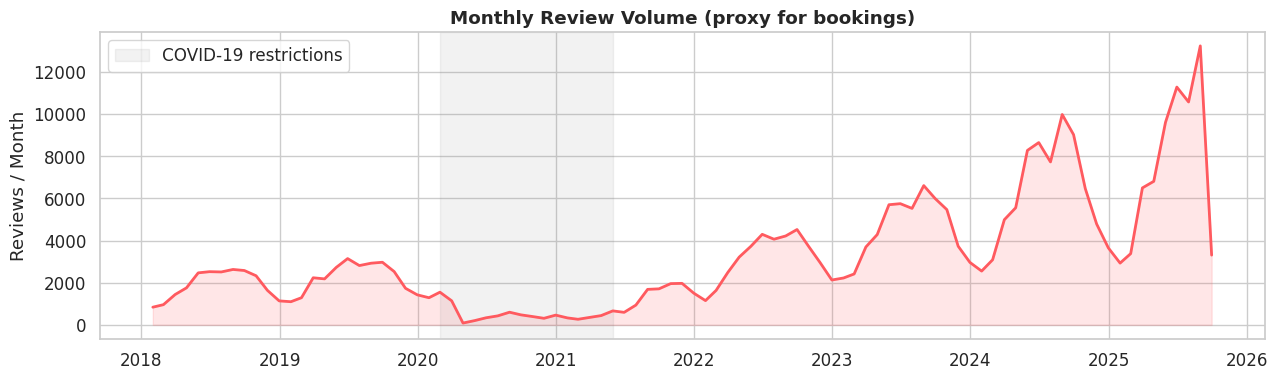

In [62]:
review_ts = (
    reviews_raw
    .assign(date=lambda x: pd.to_datetime(x['date'], errors='coerce'))
    .dropna(subset=['date'])
    .set_index('date')
    .resample('ME').size()
    .rename('review_count')
    .reset_index()
    .query('date >= "2018-01-01"')
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(data=review_ts, x='date', y='review_count', color='#FF5A5F', linewidth=2, ax=ax)
ax.fill_between(review_ts['date'], review_ts['review_count'], alpha=0.15, color='#FF5A5F')
# COVID dip is an important outlier to flag with domain knowledge
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='gray', label='COVID-19 restrictions')
ax.set_title('Monthly Review Volume (proxy for bookings)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Reviews / Month'); ax.legend()
plt.tight_layout(); plt.show()

Tourism demand in Dublin recovered strongly post-pandemic.
Seasonality indicates that tourism cycles strongly affect Airbnb activity.
Review counts increasing over time suggest market growth or increased platform adoption.

###  5.5 Superhost vs. non-superhost: price and rating
Business question: does the Superhost badge justify a price premium?

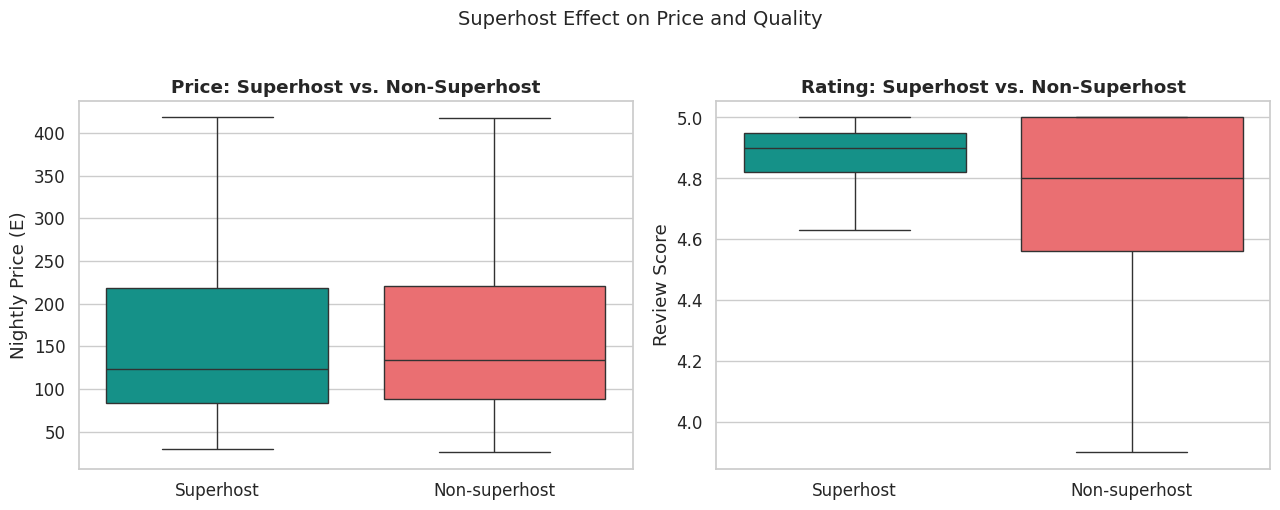

,price,review_scores_rating
superhost_label,,
Non-superhost,134.00,4.80
Superhost,123.00,4.90


In [63]:
superhost_comp = (
    df
    .assign(superhost_label=lambda x: x['is_superhost'].map({1: 'Superhost', 0: 'Non-superhost'}))
    .dropna(subset=['is_superhost', 'price', 'review_scores_rating'])
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=superhost_comp, x='superhost_label', y='price',
            palette=['#00A699', '#FF5A5F'], showfliers=False, ax=axes[0])
axes[0].set_title('Price: Superhost vs. Non-Superhost', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Nightly Price (E)')

sns.boxplot(data=superhost_comp, x='superhost_label', y='review_scores_rating',
            palette=['#00A699', '#FF5A5F'], showfliers=False, ax=axes[1])
axes[1].set_title('Rating: Superhost vs. Non-Superhost', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Review Score')

plt.suptitle('Superhost Effect on Price and Quality', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

(
    superhost_comp
    .groupby('superhost_label')[['price', 'review_scores_rating']]
    .median().round(2)
)

The Superhost badge does not justify a price premium. The median nightly price for Superhosts (€123) is slightly lower than for non-superhosts (€134). However, Superhosts have higher review ratings (4.9 vs 4.8). This suggests the Superhost badge reflects better service quality rather than higher pricing.

###  5.6 Minimum nights distribution
Business question: do many hosts enforce long stays (e.g. 30+ nights)?

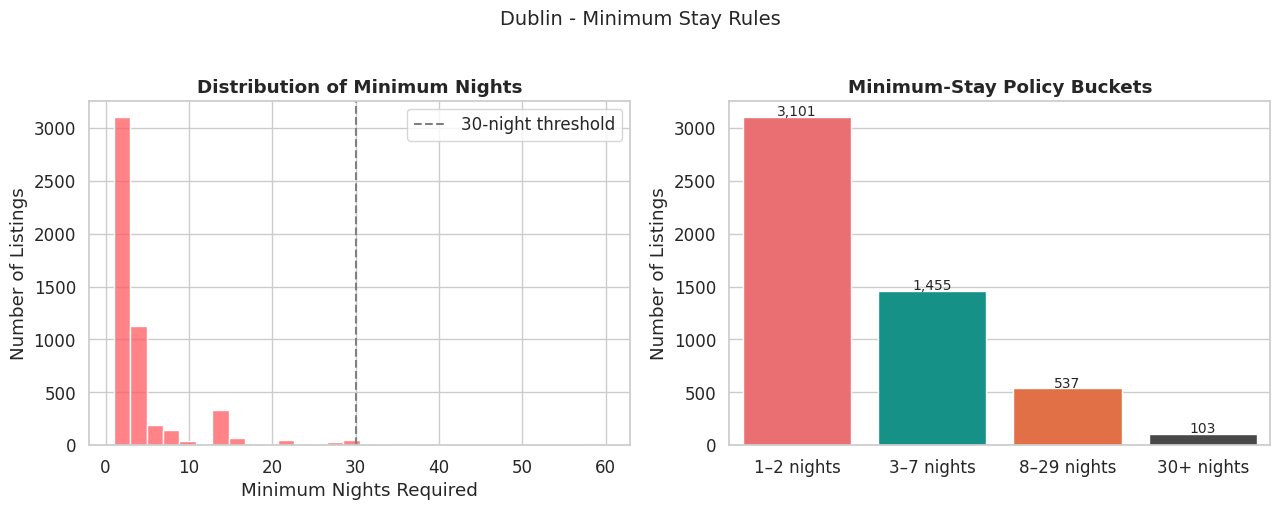

In [64]:
min_nights = df[['minimum_nights']].dropna().copy()
min_nights = min_nights[min_nights['minimum_nights'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram capped at 60 nights for readability
sns.histplot(
    data=min_nights[min_nights['minimum_nights'] <= 60],
    x='minimum_nights',
    bins=30,
    color='#FF5A5F',
    ax=axes[0]
)
axes[0].axvline(30, color='gray', linestyle='--', linewidth=1.5, label='30-night threshold')
axes[0].set_title('Distribution of Minimum Nights', fontweight='bold')
axes[0].set_xlabel('Minimum Nights Required')
axes[0].set_ylabel('Number of Listings')
axes[0].legend()

# Right: grouped policy buckets
min_nights_band = (
    min_nights
    .assign(
        min_stay_band=lambda x: pd.cut(
            x['minimum_nights'],
            bins=[0, 2, 7, 29, np.inf],
            labels=['1–2 nights', '3–7 nights', '8–29 nights', '30+ nights']
        )
    )
    ['min_stay_band']
    .value_counts(sort=False)
    .rename_axis('min_stay_band')
    .reset_index(name='n_listings')
)

sns.barplot(
    data=min_nights_band,
    x='min_stay_band',
    y='n_listings',
    palette=AIRBNB_PALETTE,
    ax=axes[1]
)
axes[1].set_title('Minimum-Stay Policy Buckets', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Listings')

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{int(bar.get_height()):,}',
        ha='center',
        fontsize=10
    )

plt.suptitle(f'{CITY_NAME} - Minimum Stay Rules', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
(
    min_nights
    .assign(is_30_plus=lambda x: (x['minimum_nights'] >= 30).astype(int))
    .agg(
        median_minimum_nights=('minimum_nights', 'median'),
        mean_minimum_nights=('minimum_nights', 'mean'),
        pct_30_plus=('is_30_plus', 'mean')
    )
    .round(2)
)

pass

Very few hosts enforce long stays of 30+ nights. Only about 103 listings fall into the 30+ night category, while the majority of listings require short stays, particularly 1–2 nights (3,101 listings) and 3–7 nights (1,455 listings).
This indicates that the Dublin Airbnb market is primarily oriented toward short-term stays, likely reflecting tourism demand rather than long-term rentals.

### 5.7 Host portfolio size
Business question: how common are multi-listers on the platform?

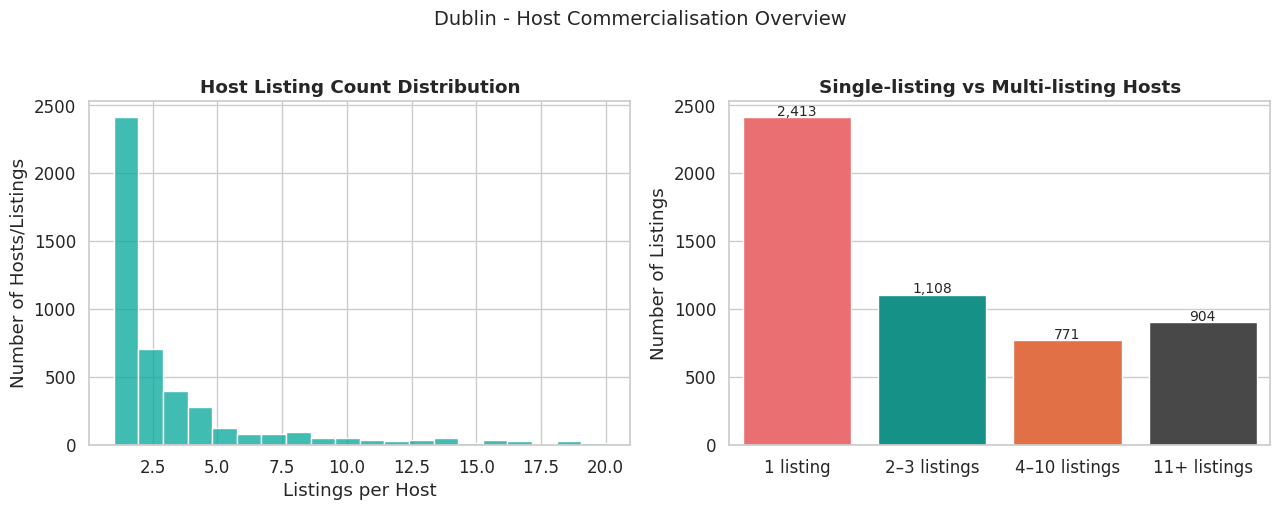

,calculated_host_listings_count,multi_lister
median_listings_per_host,2.00,NaN
mean_listings_per_host,17.14,NaN
pct_multi_lister,NaN,0.54


In [65]:


host_portfolio = df[['calculated_host_listings_count']].dropna().copy()
host_portfolio = host_portfolio[host_portfolio['calculated_host_listings_count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram capped for readability
sns.histplot(
    data=host_portfolio[host_portfolio['calculated_host_listings_count'] <= 20],
    x='calculated_host_listings_count',
    bins=20,
    color='#00A699',
    ax=axes[0]
)
axes[0].set_title('Host Listing Count Distribution', fontweight='bold')
axes[0].set_xlabel('Listings per Host')
axes[0].set_ylabel('Number of Hosts/Listings')

# Right: host type buckets
portfolio_band = (
    host_portfolio
    .assign(
        host_type=lambda x: pd.cut(
            x['calculated_host_listings_count'],
            bins=[0, 1, 3, 10, np.inf],
            labels=['1 listing', '2–3 listings', '4–10 listings', '11+ listings']
        )
    )
    ['host_type']
    .value_counts(sort=False)
    .rename_axis('host_type')
    .reset_index(name='n_listings')
)

sns.barplot(
    data=portfolio_band,
    x='host_type',
    y='n_listings',
    palette=AIRBNB_PALETTE,
    ax=axes[1]
)
axes[1].set_title('Single-listing vs Multi-listing Hosts', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Listings')

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{int(bar.get_height()):,}',
        ha='center',
        fontsize=10
    )

plt.suptitle(f'{CITY_NAME} - Host Commercialisation Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
(
    host_portfolio
    .assign(multi_lister=lambda x: (x['calculated_host_listings_count'] > 1).astype(int))
    .agg(
        median_listings_per_host=('calculated_host_listings_count', 'median'),
        mean_listings_per_host=('calculated_host_listings_count', 'mean'),
        pct_multi_lister=('multi_lister', 'mean')
    )
    .round(2)
)

Multi-listers are fairly common on the platform. While many hosts manage only one listing (2,413 listings), a substantial share belong to hosts with multiple properties. In total, about 54% of listings are managed by hosts with more than one property, indicating that multi-listing hosts represent a significant portion of the Dublin Airbnb market.
This suggests the platform includes not only individual hosts but also professional or commercial operators managing multiple listings.

**Machine Learning**

In [66]:
# Data Protection - Copying from clean dataframe
df_ml=df.copy()

STEP 1 — PREPARE DATASET FOR MACHINE LEARNING

In [67]:
for col in df.columns:
    print(f"{col:<30} | {df[col].iloc[0]}")

id                             | 44077
listing_url                    | https://www.airbnb.com/rooms/44077
scrape_id                      | 20250916040708
last_scraped                   | 2025-09-16
source                         | city scrape
name                           | cosy comfortable Irish cottage twin
description                    | Our house is a cosy comfortable cottage  with a large outdoor area  for our guests to enjoy ,we are only 6 kilometres to the city centre with great transport links by bus & tram to the city  centre & beyond <br />we have  coffee shops ,restaurants , pubs &  a large  supermarket all about 5 mins walk from here ,<br />The bus stop is 2 mins away across the road from us & the tram station is a 10 min walk with trams going into the city every 5 mins or less ,<br />Our aim is make  guests as comfortable as we can ,
neighborhood_overview          | I like our neighbourhood as there is no shortage of things to do ,there is a large Park nearby ,plus  loa

In [68]:
# 1) Make a protected working copy
df_ml = df.copy()

# 2) Basic checks
print("Shape before ML prep:", df_ml.shape)
print("Missing target values:", df_ml["price"].isna().sum())

# 3) Create / confirm target variable
# Use log_price as the prediction target because Airbnb prices are right-skewed
if "log_price" not in df_ml.columns:
    df_ml["log_price"] = np.log1p(df_ml["price"])

# 4) Convert percentage columns from strings like '95%' to numeric
pct_cols = ["host_response_rate", "host_acceptance_rate"]
for col in pct_cols:
    if col in df_ml.columns:
        df_ml[col] = (
            df_ml[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .replace("nan", np.nan)
        )
        df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")

# 5) Create amenity_count from the amenities text field
if "amenities" in df_ml.columns:
    df_ml["amenity_count"] = (
        df_ml["amenities"]
        .fillna("")
        .apply(lambda x: len([a for a in str(x).strip("{}").split(",") if a.strip() != ""]))
    )

# 6) Convert bathrooms_text to numeric bathrooms if needed
# If bathrooms already exists and is usable, keep it.
# Otherwise extract the numeric part from bathrooms_text.
if "bathrooms" in df_ml.columns:
    df_ml["bathrooms"] = pd.to_numeric(df_ml["bathrooms"], errors="coerce")

if ("bathrooms" not in df_ml.columns) or (df_ml["bathrooms"].isna().all()):
    if "bathrooms_text" in df_ml.columns:
        df_ml["bathrooms"] = (
            df_ml["bathrooms_text"]
            .astype(str)
            .str.extract(r"(\d+\.?\d*)")[0]
            .astype(float)
        )

# 7) Convert true/false host flags to numeric if not already converted
binary_map = {"t": 1, "f": 0, True: 1, False: 0}

for col in ["host_is_superhost", "host_identity_verified", "host_has_profile_pic"]:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].map(binary_map).fillna(df_ml[col])

# 8) Select candidate features for ML
# ── Split property_type into its two components ──────

### Separating Dwelling type from property type
df_ml["dwelling_type"] = (
    df_ml["property_type"]
    .str.lower()
    .str.replace(r"^(entire|room in|private room in|private room|shared room in|hotel room in)\s*", "", regex=True)
    .str.strip()
)

'''# Consolidate rare dwelling types (fewer than 1% of listings) into "other"
# to prevent OneHotEncoder from creating dozens of sparse columns
threshold = int(len(df) * 0.01)
type_counts = df_ml["dwelling_type"].value_counts()
rare_types = type_counts[type_counts < threshold].index
df_ml["dwelling_type"] = df_ml["dwelling_type"].where(
    ~df_ml["dwelling_type"].isin(rare_types), other="other"
)'''


### Distance to Central
from math import radians, cos, sin, asin, sqrt

# Dublin Center Location (O'Connell Street)
DUBLIN_CENTER_LAT = 53.3498
DUBLIN_CENTER_LON = -6.2603

def haversine_km(lat1, lon1, lat2, lon2):
   # """distance to central"""
    R = 6371  # Earth
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

df_ml["dist_to_center_km"] = df_ml.apply(
    lambda row: haversine_km(
        row["latitude"], row["longitude"],
        DUBLIN_CENTER_LAT, DUBLIN_CENTER_LON
    ),
    axis=1
)


feature_cols = [
    "room_type",
    "dwelling_type",
    "neighbourhood_cleansed",
    "accommodates",
    "bathrooms",
    "bedrooms",
    #"bathrooms_per_bedroom",
    "beds",
    "minimucm_nights",
    "host_response_rate",
    "host_acceptance_rate",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "number of reviews",
    #"instant bookable",
    "calculated_host_listings_count",
    "host_age_years",
    "is_superhost",
    "host_identity_verified",
    "amenity_count",
    #"dist_to_center_km",
    "longitude",
    "latitude"
]



Shape before ML prep: (5196, 83)
Missing target values: 0


In [69]:
for col in df_ml.columns:
    print(f"{col:<30} | {df_ml[col].iloc[0]}")

id                             | 44077
listing_url                    | https://www.airbnb.com/rooms/44077
scrape_id                      | 20250916040708
last_scraped                   | 2025-09-16
source                         | city scrape
name                           | cosy comfortable Irish cottage twin
description                    | Our house is a cosy comfortable cottage  with a large outdoor area  for our guests to enjoy ,we are only 6 kilometres to the city centre with great transport links by bus & tram to the city  centre & beyond <br />we have  coffee shops ,restaurants , pubs &  a large  supermarket all about 5 mins walk from here ,<br />The bus stop is 2 mins away across the road from us & the tram station is a 10 min walk with trams going into the city every 5 mins or less ,<br />Our aim is make  guests as comfortable as we can ,
neighborhood_overview          | I like our neighbourhood as there is no shortage of things to do ,there is a large Park nearby ,plus  loa

In [70]:
# Keep only columns that actually exist in your dataframe
feature_cols = [col for col in feature_cols if col in df_ml.columns]

# 9) Build the modeling dataframe
model_df = df_ml[feature_cols + ["price", "log_price"]].copy()

# 10) Optional: remove rows with missing target
model_df = model_df.dropna(subset=["log_price"]).reset_index(drop=True)

# 11) Quick missing-value summary
missing_summary = (
    model_df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("n_missing")
)
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(model_df) * 100).round(2)

print("\nFinal ML dataset shape:", model_df.shape)
print("\nColumns used for modeling:")
print(model_df.columns.tolist())

print("\nTop missing-value columns:")
display(missing_summary[missing_summary["n_missing"] > 0].head(15))

print("\nPreview of ML dataset:")
display(model_df.head())


Final ML dataset shape: (5196, 23)

Columns used for modeling:
['room_type', 'dwelling_type', 'neighbourhood_cleansed', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'host_age_years', 'is_superhost', 'host_identity_verified', 'amenity_count', 'longitude', 'latitude', 'price', 'log_price']

Top missing-value columns:


,n_missing,pct_missing
review_scores_location,758,14.59
review_scores_rating,758,14.59
review_scores_value,758,14.59
review_scores_communication,758,14.59
review_scores_cleanliness,758,14.59
host_response_rate,320,6.16
is_superhost,268,5.16
host_acceptance_rate,190,3.66
bedrooms,15,0.29
bathrooms,10,0.19



Preview of ML dataset:


,room_type,dwelling_type,neighbourhood_cleansed,accommodates,bathrooms,bedrooms,beds,host_response_rate,host_acceptance_rate,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,host_age_years,is_superhost,host_identity_verified,amenity_count,longitude,latitude,price,log_price
0,Private room,bungalow,Dn Laoghaire-Rathdown,2,1.00,1.00,2.00,100.00,97.00,4.82,4.77,4.93,4.68,4.83,2,15.62,1.00,1.00,55,-6.26,53.29,86.00,4.47
1,Private room,home,Dublin City,1,2.00,1.00,1.00,70.00,91.00,4.75,4.70,4.87,4.65,4.70,3,14.72,0.00,1.00,28,-6.24,53.39,48.00,3.89
2,Private room,townhouse,Dn Laoghaire-Rathdown,6,1.50,2.00,4.00,100.00,95.00,4.85,4.87,4.97,4.78,4.85,2,14.72,0.00,1.00,54,-6.19,53.28,101.00,4.62
3,Private room,home,South Dublin,1,1.50,1.00,1.00,100.00,100.00,4.92,4.86,4.98,4.67,4.86,1,14.44,1.00,1.00,30,-6.42,53.35,30.00,3.43
4,Entire home/apt,home,Dublin City,9,2.50,4.00,5.00,100.00,83.00,4.94,4.84,4.97,4.95,4.88,1,14.26,1.00,1.00,77,-6.35,53.37,130.00,4.88


In [71]:
for col in model_df.columns:
    print(f"{col:<30} | {model_df[col].iloc[1]}")

room_type                      | Private room
dwelling_type                  | home
neighbourhood_cleansed         | Dublin City
accommodates                   | 1
bathrooms                      | 2.0
bedrooms                       | 1.0
beds                           | 1.0
host_response_rate             | 70.0
host_acceptance_rate           | 91.0
review_scores_rating           | 4.75
review_scores_cleanliness      | 4.7
review_scores_communication    | 4.87
review_scores_location         | 4.65
review_scores_value            | 4.7
calculated_host_listings_count | 3
host_age_years                 | 14.723287671232876
is_superhost                   | 0.0
host_identity_verified         | 1.0
amenity_count                  | 28
longitude                      | -6.23547
latitude                       | 53.39027
price                          | 48.0
log_price                      | 3.8918202981106265


STEP 2 — SPLIT INTO X AND y, IDENTIFY FEATURE TYPES,
AND BUILD THE PREPROCESSING PIPELINE

In [72]:

# 1) Define X and y
# Use log_price as the target for modeling
X = model_df.drop(columns=["price", "log_price"])
y = model_df["log_price"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# 2) Identify numeric and categorical columns automatically
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nNumber of numeric features:", len(numeric_features))
print("Numeric features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

# 3) Build preprocessing for numeric features
# Median imputation is a safe default for numeric variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# 4) Build preprocessing for categorical features
# Most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 5) Combine preprocessing into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# 6) Train/test split
# Split AFTER defining X and y, BEFORE fitting any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain/test split complete:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 7) Optional sanity checks
print("\nMissing values in X_train (before preprocessing):")
display(X_train.isna().sum().sort_values(ascending=False).head(15))

print("\nSample rows from X_train:")
display(X_train.head())

# 8) Optional: test the preprocessor output shape
# This is just to confirm the pipeline works before attaching models
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nPreprocessing pipeline built successfully.")
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Feature matrix shape: (5196, 21)
Target vector shape: (5196,)

Number of numeric features: 18
Numeric features:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_response_rate', 'host_acceptance_rate', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'host_age_years', 'is_superhost', 'host_identity_verified', 'amenity_count', 'longitude', 'latitude']

Number of categorical features: 3
Categorical features:
['room_type', 'dwelling_type', 'neighbourhood_cleansed']

Train/test split complete:
X_train shape: (4156, 21)
X_test shape: (1040, 21)
y_train shape: (4156,)
y_test shape: (1040,)

Missing values in X_train (before preprocessing):


,0
review_scores_value,618
review_scores_rating,618
review_scores_cleanliness,618
review_scores_communication,618
review_scores_location,618
host_response_rate,250
is_superhost,221
host_acceptance_rate,146
bedrooms,10
bathrooms,9



Sample rows from X_train:


,room_type,dwelling_type,neighbourhood_cleansed,accommodates,bathrooms,bedrooms,beds,host_response_rate,host_acceptance_rate,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,host_age_years,is_superhost,host_identity_verified,amenity_count,longitude,latitude
3671,Entire home/apt,home,Dn Laoghaire-Rathdown,2,3.00,3.00,3.00,100.00,33.00,5.00,5.00,5.00,5.00,5.00,1,10.65,0.00,1.00,12,-6.11,53.28
4340,Entire home/apt,rental unit,Dublin City,4,2.00,2.00,2.00,100.00,98.00,4.14,4.18,4.64,4.32,4.14,1,0.88,0.00,1.00,25,-6.26,53.35
4118,Entire home/apt,condo,Dublin City,5,2.00,2.00,3.00,100.00,88.00,4.67,4.72,4.89,4.22,4.39,3,2.00,0.00,1.00,35,-6.25,53.35
1807,Entire home/apt,rental unit,Dublin City,6,2.00,3.00,2.00,100.00,100.00,NaN,NaN,NaN,NaN,NaN,1,8.56,0.00,1.00,9,-6.28,53.35
283,Entire home/apt,townhouse,Dublin City,5,1.00,3.00,3.00,89.00,88.00,4.79,4.74,4.85,4.91,4.73,1,10.04,0.00,1.00,65,-6.35,53.35



Preprocessing pipeline built successfully.
Processed X_train shape: (4156, 57)
Processed X_test shape: (1040, 57)


STEP 3 — DEFINE CANDIDATE MODELS AND BUILD FULL PIPELINES

In [73]:

from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Gradient boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1) Define candidate models

models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.001, max_iter=10000),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )
}




# 2) Build full sklearn pipelines
# Each pipeline = preprocessing + model

pipelines = {}

linear_model_names = {"Linear Regression", "Ridge", "Lasso"}

for model_name, model in models.items():
    prep = preprocessor_scaled if model_name in linear_model_names else preprocessor
    pipelines[model_name] = Pipeline(steps=[
        ("preprocessor", prep),
        ("model", model)
    ])

print("\nPipelines created successfully:")
for name in pipelines:
    print("-", name)

# 3) Quick pipeline sanity check
# Fit one pipeline to confirm everything works

test_model_name = "Random Forest"
test_pipeline = pipelines[test_model_name]

test_pipeline.fit(X_train, y_train)

test_predictions = test_pipeline.predict(X_test)

print("\nSanity check complete using:", test_model_name)
print("Predictions generated:", len(test_predictions))
print("First 5 predictions (log price):")
print(test_predictions[:5])

# 4) Store model names for later comparison

model_names = list(pipelines.keys())

print("\nModels ready for cross-validation comparison:")
print(model_names)


Pipelines created successfully:
- Linear Regression
- Ridge
- Lasso
- Decision Tree
- Random Forest
- Gradient Boosting
- KNN
- XGBoost
- LightGBM

Sanity check complete using: Random Forest
Predictions generated: 1040
First 5 predictions (log price):
[4.93448291 5.33550575 4.97886344 5.17940891 4.46116837]

Models ready for cross-validation comparison:
['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN', 'XGBoost', 'LightGBM']


Step 4 — CROSS-VALIDATION AND MODEL COMPARISON

In [74]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# 1) Define cross-validation strategy

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 2) Define scoring metrics for regression
# sklearn returns NEGATIVE values for RMSE / MAE scorers,
# so we will convert them back to positive later.

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

# 3) Run cross-validation for each model pipeline

cv_results = []

for model_name, pipeline in pipelines.items():

    print(f"Running cross-validation for: {model_name}")

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV RMSE Mean": -scores["test_rmse"].mean(),
        "CV RMSE Std": scores["test_rmse"].std(),
        "CV MAE Mean": -scores["test_mae"].mean(),
        "CV MAE Std": scores["test_mae"].std(),
        "CV R2 Mean": scores["test_r2"].mean(),
        "CV R2 Std": scores["test_r2"].std()
    })



Running cross-validation for: Linear Regression
Running cross-validation for: Ridge
Running cross-validation for: Lasso
Running cross-validation for: Decision Tree
Running cross-validation for: Random Forest
Running cross-validation for: Gradient Boosting
Running cross-validation for: KNN
Running cross-validation for: XGBoost
Running cross-validation for: LightGBM


In [75]:
# 4) Convert results into a dataframe

cv_results_df = pd.DataFrame(cv_results)

# Fix standard deviation sign display for RMSE / MAE
cv_results_df["CV RMSE Std"] = cv_results_df["CV RMSE Std"].abs()
cv_results_df["CV MAE Std"] = cv_results_df["CV MAE Std"].abs()

# Sort by RMSE (lower is better)
cv_results_df = cv_results_df.sort_values(
    by="CV RMSE Mean",
    ascending=True
).reset_index(drop=True)

print("\nCross-validation results (sorted by RMSE):")
display(cv_results_df)
pd.set_option('display.float_format', '{:.4f}'.format)

# 5) Optional: nicer formatting for presentation

cv_results_display = cv_results_df.copy()

metric_cols = [
    "CV RMSE Mean", "CV RMSE Std",
    "CV MAE Mean", "CV MAE Std",
    "CV R2 Mean", "CV R2 Std"
]

cv_results_display[metric_cols] = cv_results_display[metric_cols].round(5)


print("\nFormatted results table:")
display(cv_results_display)
pd.set_option('display.float_format', '{:.4f}'.format)

# 6) Identify top models

top_3_models = cv_results_df["Model"].head(3).tolist()

print("\nTop 3 models based on lowest CV RMSE:")

for i, model in enumerate(top_3_models, start=1):
    print(f"{i}. {model}")


Cross-validation results (sorted by RMSE):


,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,XGBoost,0.33,0.01,0.24,0.01,0.74,0.02
1,LightGBM,0.34,0.01,0.24,0.01,0.74,0.02
2,Gradient Boosting,0.35,0.02,0.26,0.01,0.71,0.03
3,Random Forest,0.35,0.01,0.25,0.01,0.71,0.03
4,Ridge,0.39,0.01,0.29,0.01,0.64,0.02
5,Linear Regression,0.39,0.01,0.29,0.01,0.64,0.02
6,Lasso,0.39,0.01,0.29,0.01,0.64,0.02
7,KNN,0.48,0.02,0.36,0.01,0.45,0.04
8,Decision Tree,0.50,0.02,0.35,0.01,0.41,0.05



Formatted results table:


,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std,CV R2 Mean,CV R2 Std
0,XGBoost,0.3325,0.0146,0.2401,0.0073,0.7405,0.0234
1,LightGBM,0.3359,0.0142,0.2430,0.0078,0.7354,0.0218
2,Gradient Boosting,0.3487,0.0167,0.2577,0.0083,0.7147,0.0269
3,Random Forest,0.3490,0.0148,0.2506,0.0078,0.7142,0.0253
4,Ridge,0.3917,0.0071,0.2863,0.0068,0.6404,0.0194
5,Linear Regression,0.3922,0.0074,0.2865,0.0067,0.6394,0.0197
6,Lasso,0.3939,0.0061,0.2880,0.0065,0.6363,0.0179
7,KNN,0.4826,0.0193,0.3597,0.0133,0.4538,0.0429
8,Decision Tree,0.5009,0.0164,0.3526,0.0062,0.4112,0.0479



Top 3 models based on lowest CV RMSE:
1. XGBoost
2. LightGBM
3. Gradient Boosting


STEP 4B — VISUALIZE CROSS-VALIDATION RESULTS

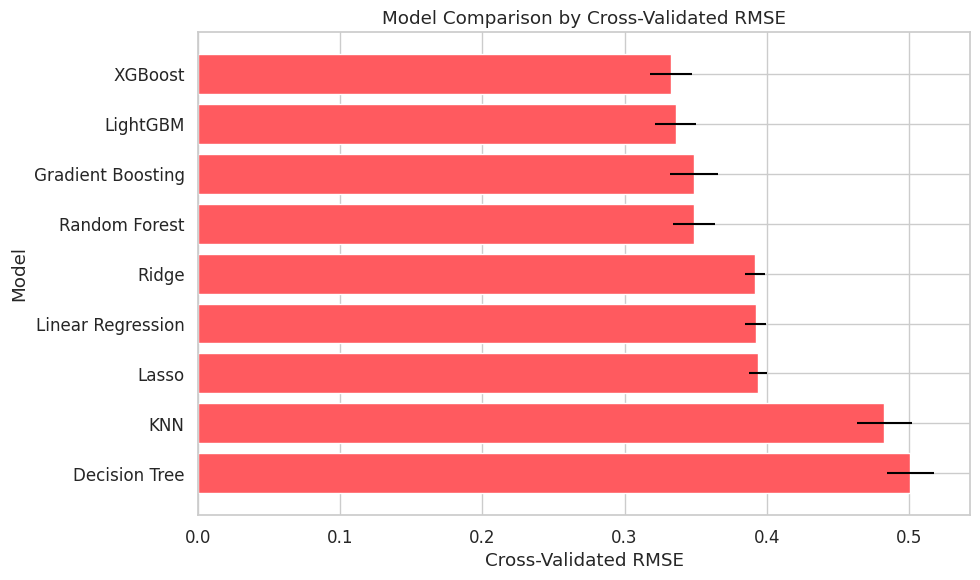

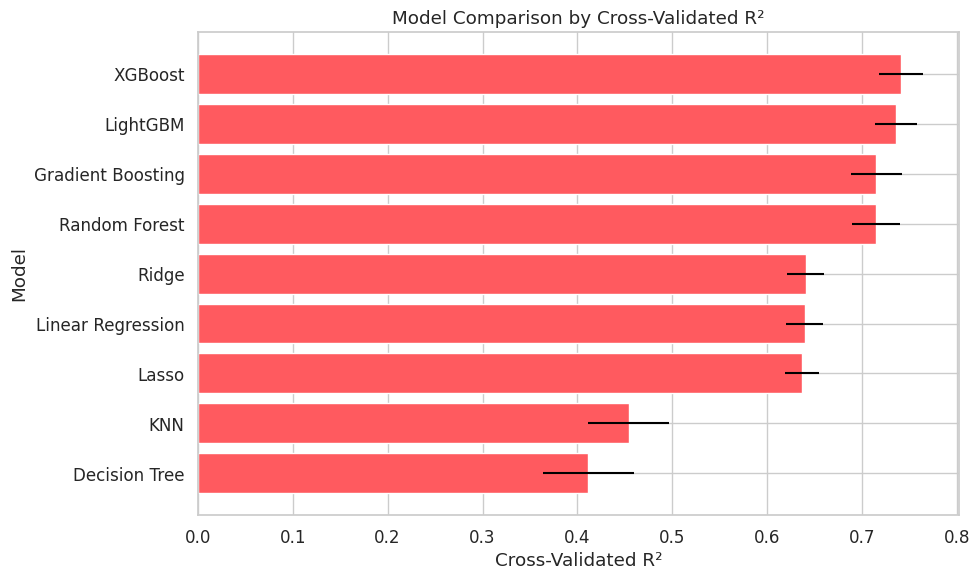

In [76]:
import matplotlib.pyplot as plt

# 1) Plot CV RMSE comparison

plt.figure(figsize=(10, 6))
plt.barh(cv_results_df["Model"], cv_results_df["CV RMSE Mean"], xerr=cv_results_df["CV RMSE Std"])
plt.xlabel("Cross-Validated RMSE")
plt.ylabel("Model")
plt.title("Model Comparison by Cross-Validated RMSE")
plt.gca().invert_yaxis()  # best model at top
plt.tight_layout()
plt.show()

# 2) Plot CV R² comparison

plt.figure(figsize=(10, 6))
plt.barh(cv_results_df["Model"], cv_results_df["CV R2 Mean"], xerr=cv_results_df["CV R2 Std"])
plt.xlabel("Cross-Validated R²")
plt.ylabel("Model")
plt.title("Model Comparison by Cross-Validated R²")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

STEP 5 — HYPERPARAMETER TUNING FOR TOP 3 MODELS


In [77]:

import time
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1) Cross-validation strategy for tuning

tuning_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 2) Define model-specific tuning configurations
#    Following the notebook's structure:
#    each entry contains:
#      - model
#      - params

tuning_configs = {

    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },

    "Ridge": {
        "model": Ridge(),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },

    "Lasso": {
        "model": Lasso(max_iter=10000, random_state=42),
        "params": {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "model__max_depth": [3, 5, 8, 12, None],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 5, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__subsample": [0.8, 1.0]
        }
    },

    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 11, 15, 21],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LightGBM": {
        "model": LGBMRegressor(
            random_state=42,
            verbose=-1
        ),
        "params": {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [-1, 5, 10],
            "model__num_leaves": [31, 50, 70],
            "model__subsample": [0.8, 1.0]
        }
    }
}

# 3) Select the top 3 models from Step 4

print("Top 3 models selected for tuning:")
for i, model_name in enumerate(top_3_models, start=1):
    print(f"{i}. {model_name}")

# Keep only the top 3 models that exist in tuning_configs
selected_tuning_configs = {
    model_name: tuning_configs[model_name]
    for model_name in top_3_models
    if model_name in tuning_configs
}

# Safety check
missing_configs = [m for m in top_3_models if m not in tuning_configs]
if missing_configs:
    print("\nWarning: No tuning configuration found for:")
    for m in missing_configs:
        print("-", m)

# 4) Run GridSearchCV for each selected model

linear_model_names = {"Linear Regression", "Ridge", "Lasso"}

grid_objects = {}
tuning_results = []

for model_name, config in selected_tuning_configs.items():

    print("\n" + "=" * 70)
    print(f"Tuning model: {model_name}")
    print("=" * 70)

    # ── Pick the right preprocessor ──────────────────────────────────────
    # Linear models need scaled numerics for fair penalisation
    # Tree-based models are scale-invariant — use the original
    prep = preprocessor_scaled if model_name in linear_model_names else preprocessor

    pipeline = Pipeline(steps=[
        ("preprocessor", prep),
        ("model", config["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        cv=tuning_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    start_time = time.time()
    grid.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    grid_objects[model_name] = grid

    tuning_results.append({
        "Model": model_name,
        "Best CV RMSE": -grid.best_score_,
        "Best Parameters": grid.best_params_,
        "Tuning Time (s)": elapsed_time
    })

    print(f"Best CV RMSE: {-grid.best_score_:.4f}")
    print("Best Parameters:")
    for param, value in grid.best_params_.items():
        clean_param = param.replace("model__", "")
        print(f"  {clean_param:<25}: {value}")

# 5) Build tuning summary table

tuning_df = pd.DataFrame(tuning_results).sort_values(
    by="Best CV RMSE",
    ascending=True
).reset_index(drop=True)

tuning_df["Rank"] = range(1, len(tuning_df) + 1)

# Reorder columns
tuning_df = tuning_df[[
    "Rank",
    "Model",
    "Best CV RMSE",
    "Tuning Time (s)",
    "Best Parameters"
]]

print("\nHyperparameter tuning summary:")
display(tuning_df)

# 6) Extract best params in a cleaner format for reporting

best_params = {}

for model_name, grid in grid_objects.items():
    best_params[model_name] = {
        k.replace("model__", ""): v
        for k, v in grid.best_params_.items()
    }

print("\nBest parameters by model:")
for model_name, params in best_params.items():
    print(f"\n{model_name}")
    for param, value in params.items():
        print(f"  {param:<25}: {value}")

Top 3 models selected for tuning:
1. XGBoost
2. LightGBM
3. Gradient Boosting

Tuning model: XGBoost
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV RMSE: 0.3318
Best Parameters:
  colsample_bytree         : 0.8
  learning_rate            : 0.05
  max_depth                : 7
  n_estimators             : 400
  subsample                : 0.8

Tuning model: LightGBM
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV RMSE: 0.3342
Best Parameters:
  learning_rate            : 0.03
  max_depth                : -1
  n_estimators             : 400
  num_leaves               : 50
  subsample                : 0.8

Tuning model: Gradient Boosting
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV RMSE: 0.3374
Best Parameters:
  learning_rate            : 0.1
  max_depth                : 4
  n_estimators             : 200
  subsample                : 0.8

Hyperparameter tuning summary:


,Rank,Model,Best CV RMSE,Tuning Time (s),Best Parameters
0,1,XGBoost,0.3318,259.3211,"{'model__colsample_bytree': 0.8, 'model__learn..."
1,2,LightGBM,0.3342,270.8870,"{'model__learning_rate': 0.03, 'model__max_dep..."
2,3,Gradient Boosting,0.3374,314.5024,"{'model__learning_rate': 0.1, 'model__max_dept..."



Best parameters by model:

XGBoost
  colsample_bytree         : 0.8
  learning_rate            : 0.05
  max_depth                : 7
  n_estimators             : 400
  subsample                : 0.8

LightGBM
  learning_rate            : 0.03
  max_depth                : -1
  n_estimators             : 400
  num_leaves               : 50
  subsample                : 0.8

Gradient Boosting
  learning_rate            : 0.1
  max_depth                : 4
  n_estimators             : 200
  subsample                : 0.8


STEP 5D — VISUALIZE HYPERPARAMETER TUNING RESULTS

In [78]:


tuning_rows = []

for model_name, grid in grid_objects.items():
    tuning_rows.append({
        "Model": model_name,
        "Best CV RMSE": -grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_df = pd.DataFrame(tuning_rows)


tuning_df = tuning_df.sort_values("Best CV RMSE", ascending=True).reset_index(drop=True)
tuning_df["Rank"] = range(1, len(tuning_df) + 1)

tuning_df = tuning_df[[
    "Rank",
    "Model",
    "Best CV RMSE",
    "Best Parameters"
]]

print("tuning_df created:")
display(tuning_df)

tuning_df created:


,Rank,Model,Best CV RMSE,Best Parameters
0,1,XGBoost,0.3318,"{'model__colsample_bytree': 0.8, 'model__learn..."
1,2,LightGBM,0.3342,"{'model__learning_rate': 0.03, 'model__max_dep..."
2,3,Gradient Boosting,0.3374,"{'model__learning_rate': 0.1, 'model__max_dept..."


Using pre-tune RMSE column: CV RMSE Mean
tuning_comparison_df created:


,Model,Pre-tune CV RMSE,Post-tune CV RMSE,Improvement
0,XGBoost,0.3325,0.3318,0.0008
1,LightGBM,0.3359,0.3342,0.0017
2,Gradient Boosting,0.3487,0.3374,0.0113


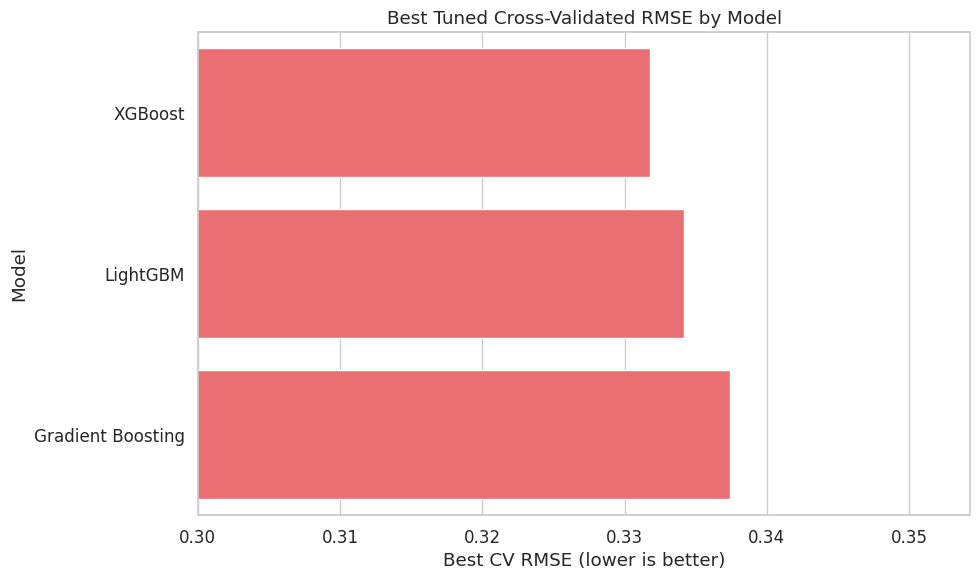

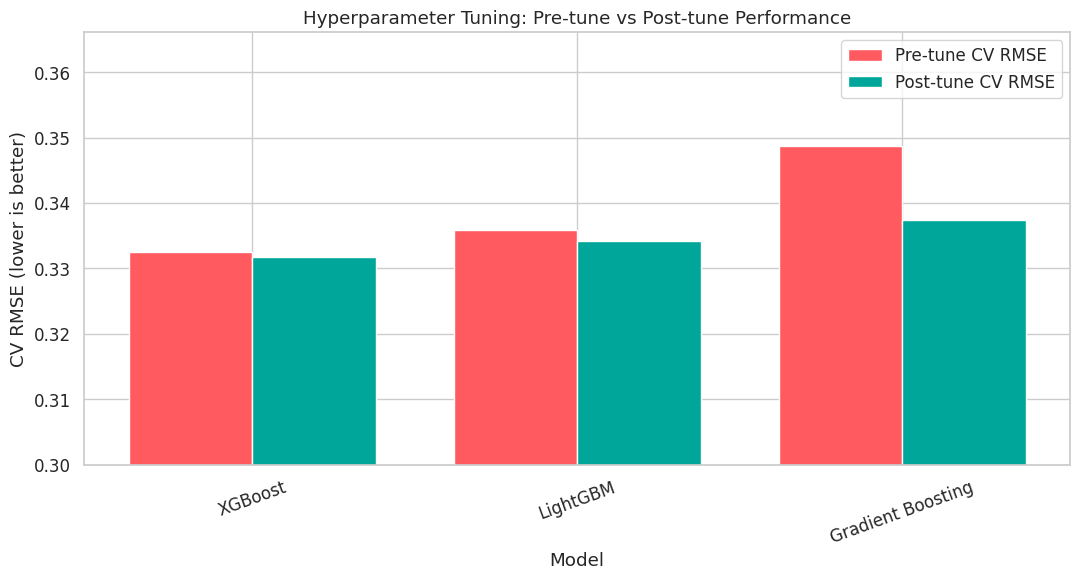

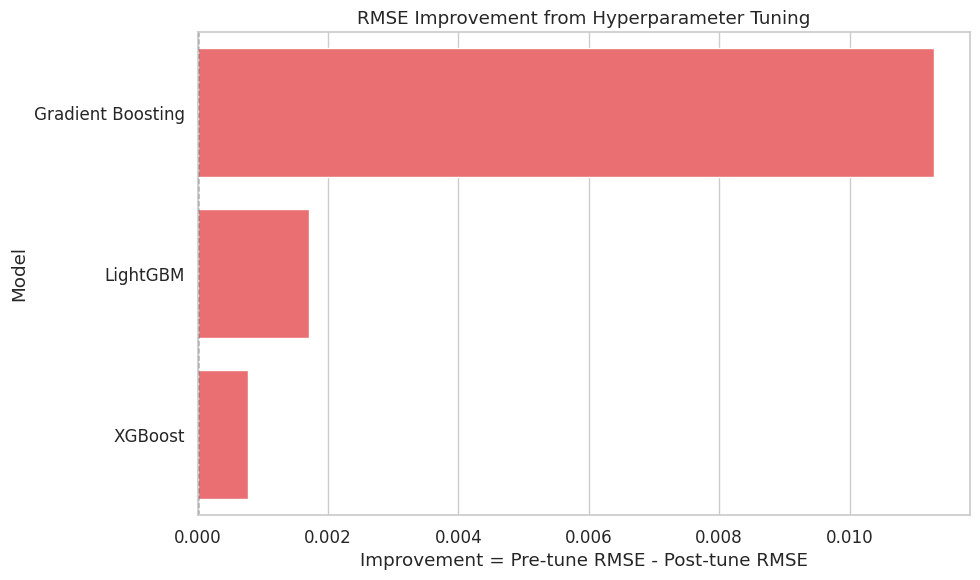

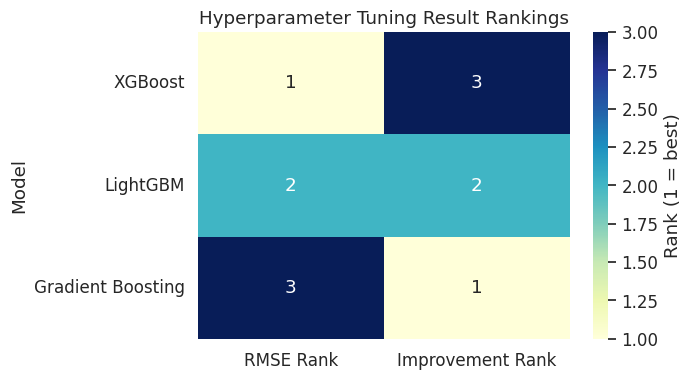

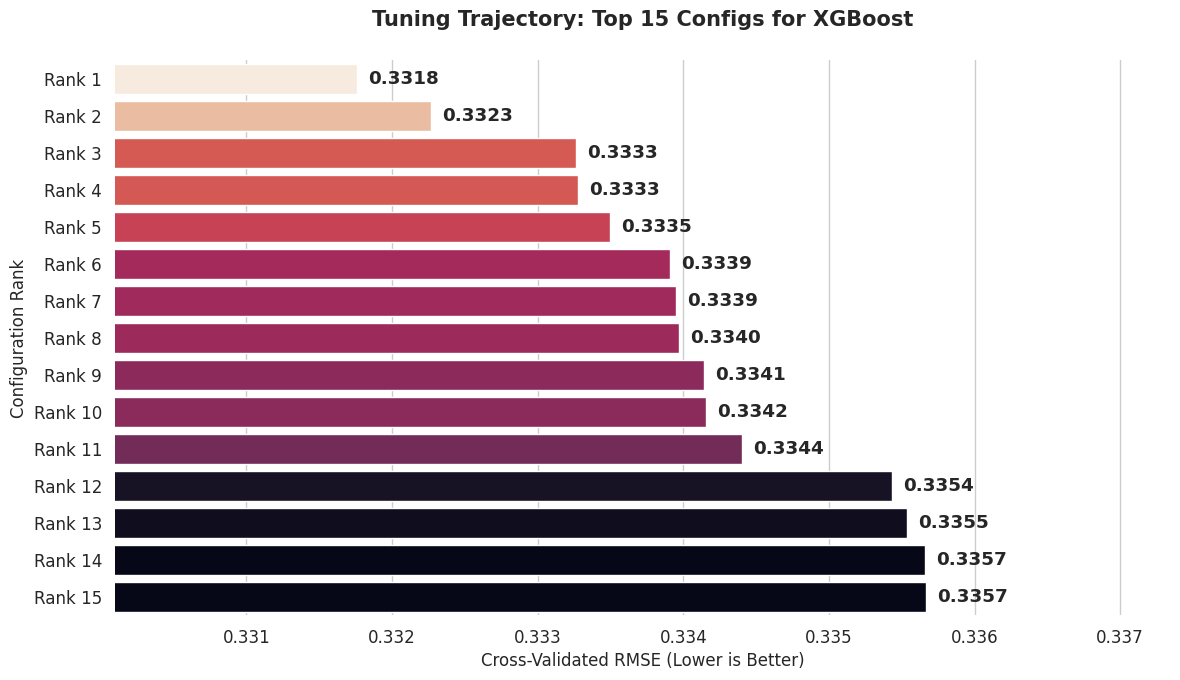

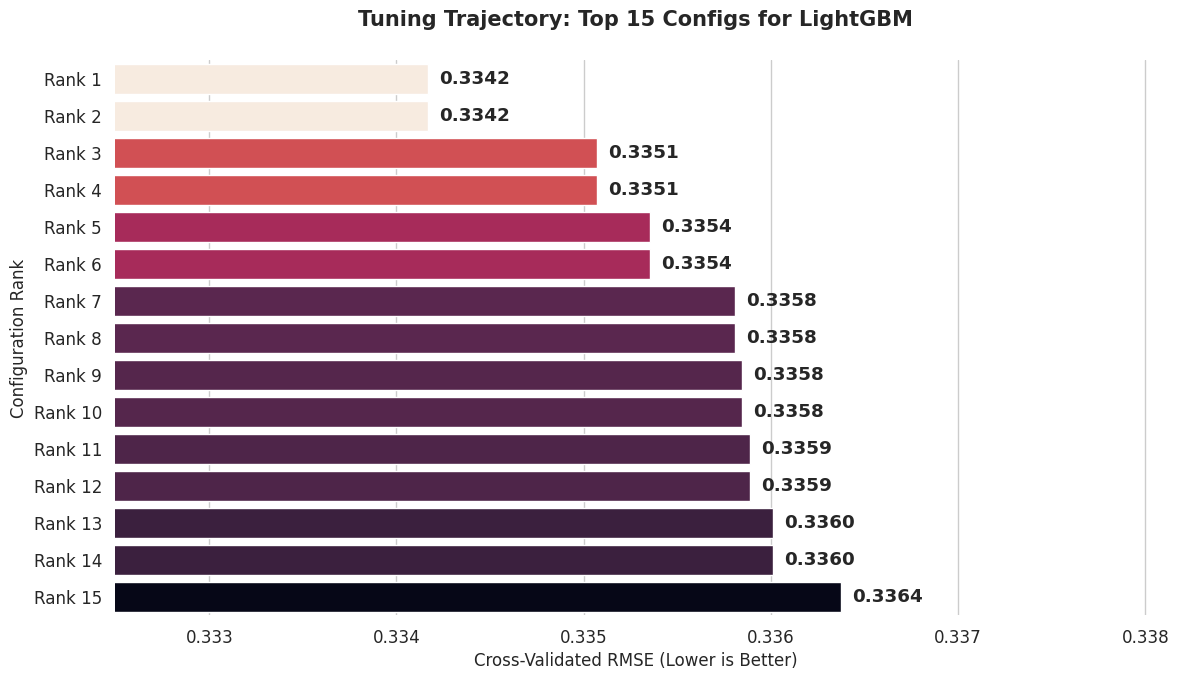

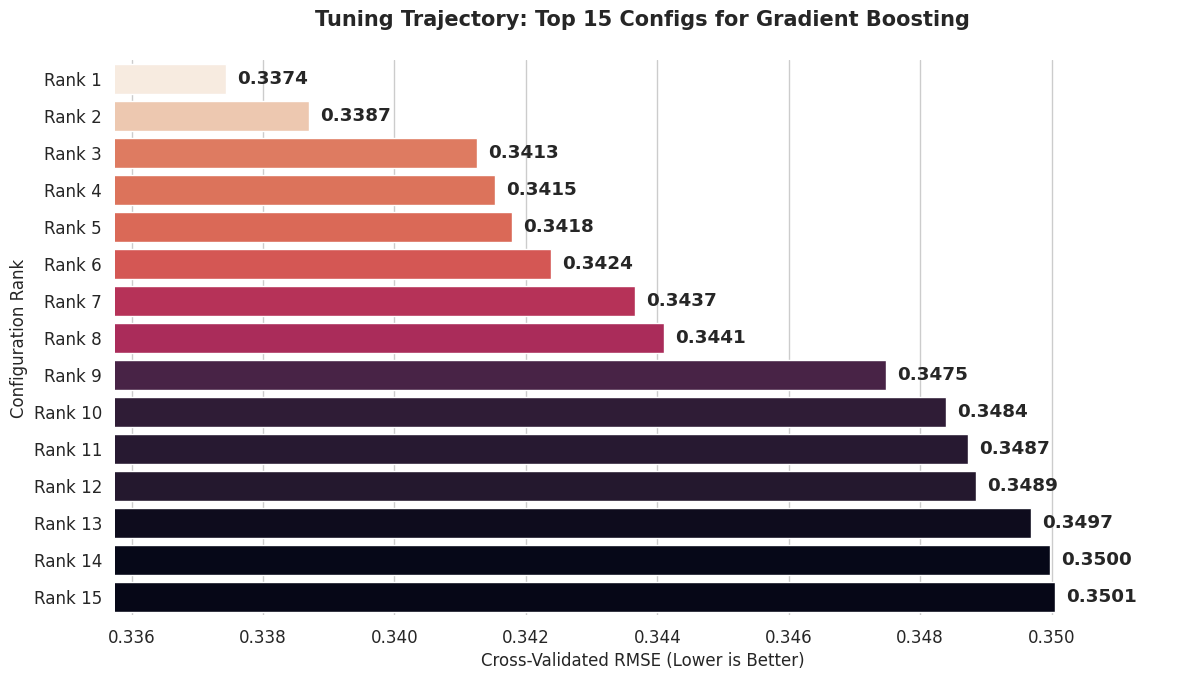

In [79]:
# Detect the RMSE column name automatically
possible_rmse_cols = ["Mean RMSE", "CV RMSE Mean", "RMSE", "Test RMSE"]
rmse_col = None

for col in possible_rmse_cols:
    if col in cv_results_df.columns:
        rmse_col = col
        break


print(f"Using pre-tune RMSE column: {rmse_col}")

pretune_lookup = cv_results_df.set_index("Model")
posttune_lookup = tuning_df.set_index("Model")

comparison_rows = []

# =============================================================================
# VISUALIZATION 1 — PRE-TUNE VS POST-TUNE RMSE
# =============================================================================

for model_name in tuning_df["Model"]:
    if model_name in pretune_lookup.index:
        pre_rmse = pretune_lookup.loc[model_name, rmse_col]
        post_rmse = posttune_lookup.loc[model_name, "Best CV RMSE"]

        comparison_rows.append({
            "Model": model_name,
            "Pre-tune CV RMSE": pre_rmse,
            "Post-tune CV RMSE": post_rmse,
            "Improvement": pre_rmse - post_rmse
        })

tuning_comparison_df = pd.DataFrame(comparison_rows)
tuning_comparison_df = tuning_comparison_df.sort_values(
    by="Post-tune CV RMSE",
    ascending=True
).reset_index(drop=True)

print("tuning_comparison_df created:")
display(tuning_comparison_df.round(4))
pd.set_option('display.float_format', '{:.6f}'.format)

plot_df = tuning_df.sort_values("Best CV RMSE", ascending=True).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="Model", x="Best CV RMSE")
plt.title("Best Tuned Cross-Validated RMSE by Model")
plt.xlabel("Best CV RMSE (lower is better)")
plt.xlim(left=0.30)
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZATION 2 — PRE-TUNE VS POST-TUNE RMSE
# =============================================================================

plot_df = tuning_comparison_df.sort_values("Post-tune CV RMSE", ascending=True).copy()

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, plot_df["Pre-tune CV RMSE"], width, label="Pre-tune CV RMSE")
plt.bar(x + width/2, plot_df["Post-tune CV RMSE"], width, label="Post-tune CV RMSE")

plt.xticks(x, plot_df["Model"], rotation=20)
plt.ylabel("CV RMSE (lower is better)")
plt.xlabel("Model")
plt.ylim(bottom=0.30)
plt.title("Hyperparameter Tuning: Pre-tune vs Post-tune Performance")
plt.legend()
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZATION 3 — IMPROVEMENT FROM TUNING
# =============================================================================

plot_df = tuning_comparison_df.sort_values("Improvement", ascending=False).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="Model", x="Improvement")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("RMSE Improvement from Hyperparameter Tuning")
plt.xlabel("Improvement = Pre-tune RMSE - Post-tune RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZATION 4 — RANKING HEATMAP
# =============================================================================

rank_df = tuning_comparison_df.copy()

rank_df["RMSE Rank"] = rank_df["Post-tune CV RMSE"].rank(ascending=True, method="min")
rank_df["Improvement Rank"] = rank_df["Improvement"].rank(ascending=False, method="min")

heatmap_df = rank_df.set_index("Model")[["RMSE Rank", "Improvement Rank"]]

plt.figure(figsize=(7, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f",
    cbar_kws={"label": "Rank (1 = best)"}
)
plt.title("Hyperparameter Tuning Result Rankings")
plt.tight_layout()
plt.show()

# =============================================================================
# VISUALIZE 5 - HYPERPARAMETER TUNING HISTORY (REGRESSION VERSION)
# =============================================================================

def plot_tuning_results(grid_search_obj, model_name):
    """
    Visualize the top-performing hyperparameter configurations
    from GridSearchCV for regression models.
    """

    # Convert GridSearch results to DataFrame
    cv_results = pd.DataFrame(grid_search_obj.cv_results_)

    # Convert negative RMSE to positive RMSE
    cv_results["RMSE"] = -cv_results["mean_test_score"]

    # Select top 15 configurations (lowest RMSE)
    top_15 = cv_results.nsmallest(15, "RMSE").copy()

    # Ranking labels
    top_15["Rank Label"] = [f"Rank {i+1}" for i in range(len(top_15))]

    # Style
    sns.set_style("whitegrid")

    # Figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Horizontal barplot
    sns.barplot(
        data=top_15,
        x="RMSE",
        y="Rank Label",
        hue="RMSE",
        palette="rocket_r",   # reversed because lower RMSE is better
        legend=False
    )

    # Titles
    ax.set_title(
        f"Tuning Trajectory: Top 15 Configs for {model_name}",
        fontsize=15,
        fontweight="bold",
        pad=25
    )

    ax.set_xlabel("Cross-Validated RMSE (Lower is Better)", fontsize=12)
    ax.set_ylabel("Configuration Rank", fontsize=12)

    # Zoom axis range
    xmin = top_15["RMSE"].min() * 0.995
    xmax = top_15["RMSE"].max() * 1.005
    ax.set_xlim(xmin, xmax)

    # Annotate scores
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.4f",
            padding=8,
            fontweight="bold"
        )

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

for name, gs in grid_objects.items():
    plot_tuning_results(gs, name)



Final Testing

In [80]:
# =============================================================================
# FINAL EVALUATION ON THE HOLD-OUT TEST SET — ALL TUNED REGRESSION MODELS
# =============================================================================
# This evaluates every tuned model on the untouched test set.
# It stores:
#   - fitted best pipeline
#   - predictions in log space
#   - predictions in original price space
#   - final regression metrics
# =============================================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# =============================================================================
# EXTRACT & DISPLAY BEST PARAMETERS PER MODEL
# =============================================================================

best_params = {}

for name in grid_objects:
    best_params[name] = grid_objects[name].best_params_

    print(f"\n{name} — Best Parameters:")
    for param, value in grid_objects[name].best_params_.items():
        clean_name = param.replace('model__', '')
        print(f"  {clean_name:<25}: {value}")
# =============================================================================
# EVALUATE ALL TUNED MODELS ON THE HOLD-OUT TEST SET
# =============================================================================

all_results = {}

# Actual values in original price space
y_test_price = np.expm1(y_test)

for model_name in tuning_df["Model"]:

    # Best tuned pipeline from GridSearchCV
    pipeline = grid_objects[model_name].best_estimator_

    # Predict in log space
    y_pred_log = pipeline.predict(X_test)

    # Convert predictions back to original euro price space
    y_pred_price = np.expm1(y_pred_log)

    # -----------------------------
    # Metrics in log space
    # -----------------------------
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)

    # -----------------------------
    # Metrics in original price space
    # -----------------------------
    rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
    mae_price = mean_absolute_error(y_test_price, y_pred_price)
    r2_price = r2_score(y_test_price, y_pred_price)
    mape_price = mean_absolute_percentage_error(y_test_price, y_pred_price)
    medae_price = median_absolute_error(y_test_price, y_pred_price)

    final_metrics = {
        "RMSE (log)": rmse_log,
        "MAE (log)": mae_log,
        "R² (log)": r2_log,
        "RMSE (€)": rmse_price,
        "MAE (€)": mae_price,
        "R² (€)": r2_price,
        "MAPE": mape_price,
        "Median AE (€)": medae_price
    }

    all_results[model_name] = {
        "pipeline": pipeline,
        "y_pred_log": y_pred_log,
        "y_pred_price": y_pred_price,
        "metrics": final_metrics
    }


XGBoost — Best Parameters:
  colsample_bytree         : 0.8
  learning_rate            : 0.05
  max_depth                : 7
  n_estimators             : 400
  subsample                : 0.8

LightGBM — Best Parameters:
  learning_rate            : 0.03
  max_depth                : -1
  n_estimators             : 400
  num_leaves               : 50
  subsample                : 0.8

Gradient Boosting — Best Parameters:
  learning_rate            : 0.1
  max_depth                : 4
  n_estimators             : 200
  subsample                : 0.8


In [82]:
# =============================================================================
# SUMMARY TABLE — ROWS = METRICS, COLUMNS = MODELS
# =============================================================================

comparison_df = pd.DataFrame(
    {name: res["metrics"] for name, res in all_results.items()}
)

# Append tuning / CV time if available
time_col = None
for candidate in ["Tuning Time (s)", "Time Taken (s)"]:
    if candidate in tuning_df.columns:
        time_col = candidate
        break

if time_col is not None:
    cv_times = tuning_df.set_index("Model")[time_col].to_dict()
    comparison_df.loc["CV Time (s)"] = {
        name: cv_times.get(name, np.nan) for name in comparison_df.columns
    }

# Create formatted display version
display_df = comparison_df.copy()

for idx in display_df.index:
    for col in display_df.columns:
        v = display_df.loc[idx, col]

        if pd.isna(v):
            display_df.loc[idx, col] = "NA"
        elif idx == "CV Time (s)":
            display_df.loc[idx, col] = f"{v:.2f}s"
        elif idx == "MAPE":
            display_df.loc[idx, col] = f"{v:.1%}"
        elif "R²" in idx:
            display_df.loc[idx, col] = f"{v:.4f}"
        else:
            display_df.loc[idx, col] = f"{v:.2f}"

print("\n" + "=" * 90)
print(f"{'MODEL COMPARISON — TEST SET PERFORMANCE':^90}")
print("=" * 90)
print(display_df.to_string())
print("=" * 90)


                         MODEL COMPARISON — TEST SET PERFORMANCE                          
              XGBoost LightGBM Gradient Boosting
RMSE (log)       0.32     0.33              0.34
MAE (log)        0.23     0.23              0.24
R² (log)       0.7536   0.7417            0.7332
RMSE (€)        85.91    89.46             89.08
MAE (€)         46.06    47.61             48.33
R² (€)         0.6136   0.5810            0.5846
MAPE            24.2%    24.6%             25.6%
Median AE (€)   22.83    22.85             24.81


In [83]:
# =============================================================================
# BEST MODEL PER METRIC — REGRESSION VERSION
# =============================================================================
# Assumes:
#   1) comparison_df already exists
#   2) comparison_df rows are metrics and columns are model names
#
# Expected metric rows include:
#   - RMSE (log)
#   - MAE (log)
#   - R² (log)
#   - RMSE (€)
#   - MAE (€)
#   - R² (€)
#   - MAPE
#   - Median AE (€)
#   - CV Time (s)   [optional]
#
# Logic:
#   - Lower is better for error metrics and time
#   - Higher is better for R²
# =============================================================================

print("\n" + "=" * 80)
print(f"{'BEST MODEL PER METRIC':^80}")
print("=" * 80)

best_model_summary = []

for metric in comparison_df.index:

    # convert row to numeric safely
    metric_values = pd.to_numeric(comparison_df.loc[metric], errors="coerce")

    # skip rows with no numeric values
    if metric_values.isna().all():
        print(f"  {metric:<24}: No valid numeric values")
        continue

    # choose best model depending on metric type
    if metric == "CV Time (s)":
        best_model = metric_values.idxmin()
        best_value = metric_values[best_model]
        print(f"  {'Fastest CV':<24}: {best_model}  ({best_value:.2f}s)")

    elif metric in ["R² (log)", "R² (€)"]:
        best_model = metric_values.idxmax()
        best_value = metric_values[best_model]
        print(f"  {metric:<24}: {best_model}  ({best_value:.4f})")

    elif metric == "MAPE":
        best_model = metric_values.idxmin()
        best_value = metric_values[best_model]
        print(f"  {metric:<24}: {best_model}  ({best_value:.1%})")

    else:
        # all other regression error metrics: lower is better
        best_model = metric_values.idxmin()
        best_value = metric_values[best_model]
        print(f"  {metric:<24}: {best_model}  ({best_value:.2f})")

    # store for summary dataframe
    best_model_summary.append({
        "Metric": metric if metric != "CV Time (s)" else "Fastest CV",
        "Best Model": best_model,
        "Best Value": best_value
    })

print("=" * 80)

# =============================================================================
# SUMMARY DATAFRAME OF BEST MODEL PER METRIC
# =============================================================================

best_model_per_metric_df = pd.DataFrame(best_model_summary)

def format_best_value(row):
    metric = row["Metric"]
    value = row["Best Value"]

    if metric == "Fastest CV":
        return f"{value:.2f}s"
    elif metric == "MAPE":
        return f"{value:.1%}"
    elif metric in ["R² (log)", "R² (€)"]:
        return f"{value:.4f}"
    else:
        return f"{value:.2f}"

best_model_per_metric_df["Formatted Value"] = best_model_per_metric_df.apply(
    format_best_value,
    axis=1
)

best_model_per_metric_df = best_model_per_metric_df[[
    "Metric", "Best Model", "Formatted Value"
]]

print("\nSummary table — Best model per metric:")
display(best_model_per_metric_df)


                             BEST MODEL PER METRIC                              
  RMSE (log)              : XGBoost  (0.32)
  MAE (log)               : XGBoost  (0.23)
  R² (log)                : XGBoost  (0.7536)
  RMSE (€)                : XGBoost  (85.91)
  MAE (€)                 : XGBoost  (46.06)
  R² (€)                  : XGBoost  (0.6136)
  MAPE                    : XGBoost  (24.2%)
  Median AE (€)           : XGBoost  (22.83)

Summary table — Best model per metric:


,Metric,Best Model,Formatted Value
0,RMSE (log),XGBoost,0.32
1,MAE (log),XGBoost,0.23
2,R² (log),XGBoost,0.7536
3,RMSE (€),XGBoost,85.91
4,MAE (€),XGBoost,46.06
5,R² (€),XGBoost,0.6136
6,MAPE,XGBoost,24.2%
7,Median AE (€),XGBoost,22.83


Feature Importance Analysis

Winning model (lowest test RMSE): XGBoost
Test RMSE (€): 85.91
Test MAE (€):  46.06
Test R² (€):   0.6136
Number of processed features: 57
Top 20 features identified:


,Feature,Importance,Importance Share
0,room_type_Entire home/apt,0.154293,0.154293
1,bedrooms,0.119921,0.119921
2,accommodates,0.106261,0.106261
3,room_type_Private room,0.091645,0.091645
4,room_type_Shared room,0.088168,0.088168
5,dwelling_type_hotel,0.044527,0.044527
6,dwelling_type_hostel,0.043214,0.043214
7,room_type_Hotel room,0.037074,0.037074
8,dwelling_type_serviced apartment,0.020794,0.020794
9,dwelling_type_chalet,0.017954,0.017954


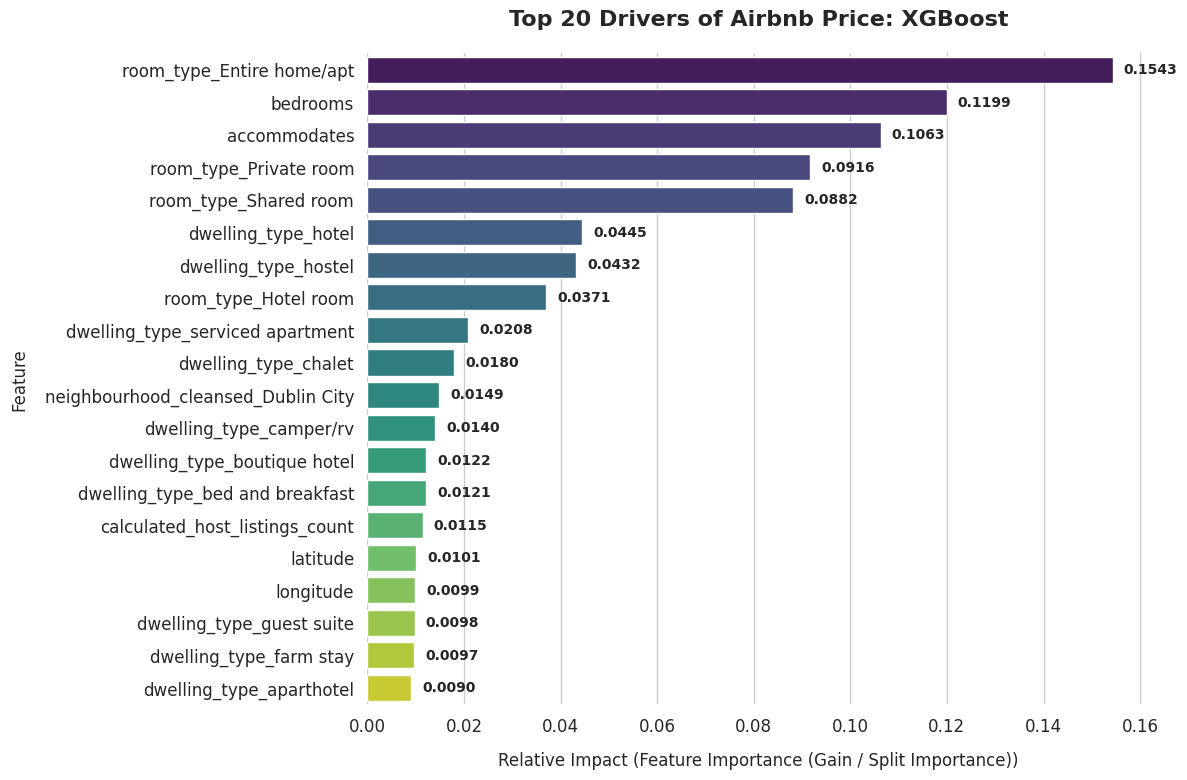


╔════════════════════════════════════════════════════════════════════════╗
║                     TOP 20 PRICE DRIVERS: XGBOOST                      ║
╠════════════════════════════════════════════════════════════════════════╣
║  room_type_Entire home/apt              :     0.1543   ( 15.43%)  ║
║  bedrooms                               :     0.1199   ( 11.99%)  ║
║  accommodates                           :     0.1063   ( 10.63%)  ║
║  room_type_Private room                 :     0.0916   (  9.16%)  ║
║  room_type_Shared room                  :     0.0882   (  8.82%)  ║
║  dwelling_type_hotel                    :     0.0445   (  4.45%)  ║
║  dwelling_type_hostel                   :     0.0432   (  4.32%)  ║
║  room_type_Hotel room                   :     0.0371   (  3.71%)  ║
║  dwelling_type_serviced apartment       :     0.0208   (  2.08%)  ║
║  dwelling_type_chalet                   :     0.0180   (  1.80%)  ║
║  neighbourhood_cleansed_Dublin City     :     0.0149   (  1.49%)  ║
║  d

In [84]:
# =============================================================================
# IDENTIFY THE WINNING MODEL FROM FINAL TEST-SET PERFORMANCE
# =============================================================================
# For regression, choose the winner by LOWEST TEST RMSE IN EURO SPACE

winning_model_name = min(
    all_results,
    key=lambda name: all_results[name]["metrics"]["RMSE (€)"]
)

best_pipeline = all_results[winning_model_name]["pipeline"]

print(f"Winning model (lowest test RMSE): {winning_model_name}")
print(f"Test RMSE (€): {all_results[winning_model_name]['metrics']['RMSE (€)']:.2f}")
print(f"Test MAE (€):  {all_results[winning_model_name]['metrics']['MAE (€)']:.2f}")
print(f"Test R² (€):   {all_results[winning_model_name]['metrics']['R² (€)']:.4f}")


# =============================================================================
# EXTRACT THE TRAINED REGRESSOR AND FEATURE NAMES
# =============================================================================
# In your regression pipeline, the final estimator is stored under 'model'

final_model = best_pipeline.named_steps["model"]

# Extract processed feature names from the preprocessor
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"Number of processed features: {len(feature_names)}")

# =============================================================================
# COMPUTE FEATURE IMPORTANCE
# =============================================================================
# Logic:
#   - Tree models expose .feature_importances_
#   - Linear models expose .coef_
#   - We take absolute coefficients for linear models

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_
    metric_name = "Feature Importance (Gain / Split Importance)"

elif hasattr(final_model, "coef_"):
    coef_values = np.ravel(final_model.coef_)
    importances = np.abs(coef_values)
    metric_name = "Feature Importance (Absolute Coefficients)"

else:
    raise AttributeError(
        f"The winning model '{winning_model_name}' does not expose "
        f"'feature_importances_' or 'coef_'."
    )

# Build ranked importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Clean feature names for readability
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Optional: normalize importances to percentages of total contribution
importance_df["Importance Share"] = importance_df["Importance"] / importance_df["Importance"].sum()

# Top 10 for plotting
top_20_features = importance_df.head(20).copy()

print("Top 20 features identified:")
display(top_20_features)


# =============================================================================
# VISUALIZING GLOBAL FEATURE DRIVERS
# =============================================================================

sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature",
    palette="viridis",
    hue="Feature",
    legend=False
)

plt.title(
    f"Top 20 Drivers of Airbnb Price: {winning_model_name}",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel(f"Relative Impact ({metric_name})", fontsize=12, labelpad=12)
plt.ylabel("Feature", fontsize=12, labelpad=12)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=8,
        fontsize=10,
        fontweight="bold"
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()



# =============================================================================
# QUANTITATIVE DRIVER SUMMARY
# =============================================================================

print("\n" + "╔" + "═" * 72 + "╗")
print(f"║{f' TOP 20 PRICE DRIVERS: {winning_model_name.upper()} ':^72}║")
print("╠" + "═" * 72 + "╣")

for _, row in top_20_features.iterrows():
    print(
        f"║  {row['Feature']:<38} : "
        f"{row['Importance']:>10.4f}   "
        f"({row['Importance Share']*100:>6.2f}%)  ║"
    )

print("╚" + "═" * 72 + "╝")


In [88]:
import os
import pandas as pd

os.makedirs("data/ml_outputs", exist_ok=True)

cv_results_df.to_csv("data/ml_outputs/cv_results.csv", index=False)
tuning_df.to_csv("data/ml_outputs/tuning_results.csv", index=False)
tuning_comparison_df.to_csv("data/ml_outputs/tuning_comparison.csv", index=False)

comparison_df.T.reset_index().rename(columns={"index": "Model"}).to_csv(
    "data/ml_outputs/test_comparison.csv", index=False
)

best_model_per_metric_df.to_csv("data/ml_outputs/best_model_per_metric.csv", index=False)
top_20_features.to_csv("data/ml_outputs/top_20_features.csv", index=False)

winner_summary = pd.DataFrame([{
    "winning_model_name": winning_model_name,
    "rmse_eur": all_results[winning_model_name]["metrics"]["RMSE (€)"],
    "mae_eur": all_results[winning_model_name]["metrics"]["MAE (€)"],
    "r2_eur": all_results[winning_model_name]["metrics"]["R² (€)"],
}])
winner_summary.to_csv("data/ml_outputs/winner_summary.csv", index=False)